In [31]:
# ==============================================================
# 1) Setup & imports — IoU between GEE_SW and DEM_SW (Kivu & Tanganyika)
# ==============================================================

# If needed in your ArcGIS Pro conda env:
# !pip install -q geopandas shapely pyproj pandas numpy tqdm matplotlib rasterio

from pathlib import Path
import re
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass

import numpy as np
import pandas as pd
from tqdm import tqdm

import geopandas as gpd
from shapely.ops import unary_union
from shapely.geometry import shape as shp_shape, Polygon, MultiPolygon, LineString, MultiLineString
from shapely import prepared
from shapely import affinity
from shapely import geometry as sgeom

from pyproj import CRS, Transformer, Geod

import matplotlib.pyplot as plt

In [2]:
# ==============================================================
# 2) User settings — folders, switches, test mode, plotting
# ==============================================================

# --- INPUT ROOTS ---
VECTORS_ROOT = Path(r"C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\vectors")
DEM_SW_DIR   = VECTORS_ROOT / "DEM_SW"
GEE_SW_DIR   = VECTORS_ROOT / "GEE_SW"

# DEM subfolders (each contains its lake’s files)
DEM_SUBFOLDERS = {
    "Tanganyika": DEM_SW_DIR / "Tanganyika_16",
    "Kivu":       DEM_SW_DIR / "Kivu_162",
}

# HydroLAKES AOI (for local equal-area + sanity)
AOI_DIR = Path(r"C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\aoi")
AOI_FILES = {
    "Tanganyika": AOI_DIR / "HydroLAKES_polys_v10_Tanganyika.shp",
    "Kivu":       AOI_DIR / "HydroLAKES_polys_v10_Kivu.shp",
}

# --- OUTPUTS ---
IOU_ROOT   = Path(r"C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU")
STATS_DIR  = IOU_ROOT / "stats"
PLOTS_DIR  = STATS_DIR / "plots"
TABLES_DIR = STATS_DIR / "tables"
for d in [IOU_ROOT, STATS_DIR, PLOTS_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --- PROCESSING SWITCHES ---
LAKES_TO_PROCESS = ["Tanganyika", "Kivu"]  # subset like ["Tanganyika"] for tests
RUN_ONLY_YYYY_MM = None  # e.g., "2024_07" to process one month; or None for all matches
DISSOLVE_INPUTS  = True  # dissolve each side to a single (multi)polygon before metrics
FIX_INVALID      = True  # apply .buffer(0) to clean minor topology errors

# CRS / area computation
PREFER_DEM_CRS_IF_EQUAL_AREA = True  # if DEM is in Equal-Area, use it as working CRS
GEOD = Geod(ellps="WGS84")           # for sanity geodesic checks if needed (not required)

# Extra metrics (optional compute time)
COMPUTE_PRECISION_RECALL = True      # Treat GEE as reference (ground-ish truth)
COMPUTE_SYM_DIFF_AREA    = True      # km² of disagreement
COMPUTE_BOUNDARY_METRICS = False     # boundary distances can be heavy; enable if needed 
                                     # I keep it false and run it separatelly afterwards,
BOUNDARY_SAMPLE_EVERY_M  = 2000.0    # sampling interval along boundaries (meters) if enabled

# Plotting
MAKE_PLOTS = True
SAVE_PNG_DPI = 150


In [3]:
# ==============================================================
# 3) Helpers — file discovery & name parsing for pairing
# ==============================================================

# DEM file pattern example:
#  "Tanganyika_16_202503_mean_772_13_30mBuff_sel_diss.shp"
DEM_RE = re.compile(r"^(Tanganyika|Kivu)_[^_]*_(\d{6})_.*_diss\.(shp|gpkg)$", re.IGNORECASE)

# GEE file pattern example (from previous script):
#  "sw_2025_03_Tanganyika.shp" or ".gpkg"
GEE_RE = re.compile(r"^sw_(\d{4})_(\d{2})_(Tanganyika|Kivu)\.(shp|gpkg)$", re.IGNORECASE)

def parse_dem_name(p: Path) -> Optional[Tuple[str, int, int]]:
    m = DEM_RE.match(p.name)
    if not m:
        return None
    lake = m.group(1).title()
    yyyymm = m.group(2)
    year = int(yyyymm[:4]); month = int(yyyymm[4:])
    return lake, year, month

def parse_gee_name(p: Path) -> Optional[Tuple[str, int, int]]:
    m = GEE_RE.match(p.name)
    if not m:
        return None
    year = int(m.group(1)); month = int(m.group(2))
    lake = m.group(3).title()
    return lake, year, month

def find_dem_files() -> Dict[Tuple[str,int,int], Path]:
    idx = {}
    for lake, folder in DEM_SUBFOLDERS.items():
        if not folder.exists():
            continue
        for p in folder.rglob("*_diss.shp"):
            info = parse_dem_name(p)
            if info: idx[(info[0], info[1], info[2])] = p
        for p in folder.rglob("*_diss.gpkg"):
            info = parse_dem_name(p)
            if info: idx[(info[0], info[1], info[2])] = p
    return idx

def find_gee_files() -> Dict[Tuple[str,int,int], Path]:
    idx = {}
    for lake in ["Tanganyika", "Kivu"]:
        folder = GEE_SW_DIR / lake
        if not folder.exists():
            continue
        for p in folder.glob("sw_????_??_*.shp"):
            info = parse_gee_name(p)
            if info: idx[(info[0], info[1], info[2])] = p
        for p in folder.glob("sw_????_??_*.gpkg"):
            info = parse_gee_name(p)
            if info: idx[(info[0], info[1], info[2])] = p
    return idx


In [4]:
# ==============================================================
# 4) CRS tools — choose a working equal-area CRS per lake
# ==============================================================

def load_aoi(lake: str) -> sgeom.base.BaseGeometry:
    g = gpd.read_file(AOI_FILES[lake]).to_crs("EPSG:4326")
    geom = unary_union(g.geometry)
    return geom.buffer(0)

def local_laea_crs(geom_wgs84: sgeom.base.BaseGeometry) -> CRS:
    c = geom_wgs84.centroid
    return CRS.from_proj4(f"+proj=laea +lat_0={c.y} +lon_0={c.x} +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs")

def is_equal_area(crs: CRS) -> bool:
    if crs is None or not crs.is_projected:
        return False
    s = (crs.to_string() or "").lower()
    s += " " + (crs.to_wkt() or "").lower()
    # heuristics: LAEA or "equal area" in name
    return ("laea" in s) or ("equal" in s and "area" in s)

def choose_work_crs(lake: str, dem_path: Optional[Path], gee_path: Optional[Path]) -> CRS:
    """
    Prefer DEM CRS if it exists and is equal-area; else use local LAEA centered on HydroLAKES AOI.
    """
    aoi = load_aoi(lake)
    if PREFER_DEM_CRS_IF_EQUAL_AREA and dem_path is not None:
        try:
            dem_crs = gpd.read_file(dem_path).crs
            if dem_crs and is_equal_area(CRS.from_user_input(dem_crs)):
                return CRS.from_user_input(dem_crs)
        except Exception:
            pass
    return local_laea_crs(aoi)


In [5]:
# ==============================================================
# 5) Geometry I/O — read, dissolve, fix, and reproject to work CRS
# ==============================================================

def read_single_multipart_polygon(vec_path: Path, work_crs: CRS, dissolve: bool=True, fix_invalid: bool=True) -> Optional[sgeom.base.BaseGeometry]:
    """
    Read vector, dissolve to a single (multi)polygon if requested, fix minor invalids, and reproject to work_crs.
    Returns shapely geometry or None if empty/missing.
    """
    if not vec_path or not vec_path.exists():
        return None
    try:
        gdf = gpd.read_file(vec_path)
        if gdf.empty or gdf.geometry.is_empty.all():
            return None
        # dissolve to single geometry if needed
        geom = unary_union(gdf.geometry) if dissolve else unary_union(gdf.geometry)  # ensure single geom either way
        if fix_invalid:
            geom = geom.buffer(0)
        # ensure CRS and reproject
        if gdf.crs is None:
            # assume EPSG:4326 if missing; adjust if you know otherwise
            gdf = gdf.set_crs("EPSG:4326")
        proj = gpd.GeoSeries([geom], crs=gdf.crs).to_crs(work_crs)
        return proj.iloc[0]
    except Exception as e:
        print(f"[warn] Failed reading {vec_path.name}: {e}")
        return None

def area_km2(geom: sgeom.base.BaseGeometry) -> float:
    if not geom or geom.is_empty:
        return 0.0
    return float(geom.area) / 1e6  # since work CRS uses meters


In [6]:
# ==============================================================
# 6) Pairing — build month matches (lake, year, month) across DEM & GEE
# ==============================================================

dem_idx = find_dem_files()
gee_idx = find_gee_files()

pairs = []
for (lake, y, m), dem_path in dem_idx.items():
    if lake not in LAKES_TO_PROCESS:
        continue
    gee_path = gee_idx.get((lake, y, m))
    if not gee_path:
        continue  # skip months without a counterpart
    yyyymm = f"{y:04d}_{m:02d}"
    if RUN_ONLY_YYYY_MM and yyyymm != RUN_ONLY_YYYY_MM:
        continue
    pairs.append((lake, y, m, dem_path, gee_path))

pairs = sorted(pairs, key=lambda t: (t[0], t[1], t[2]))
print(f"Matched pairs: {len(pairs)}")
print("First 5:", [(p[0], p[1], p[2]) for p in pairs[:5]])


Matched pairs: 34
First 5: [('Kivu', 2023, 11), ('Kivu', 2023, 12), ('Kivu', 2024, 1), ('Kivu', 2024, 2), ('Kivu', 2024, 3)]


In [7]:
# ==============================================================
# 7) Metrics — IoU, precision/recall (GEE as reference), symmetric diff, boundary distances
# ==============================================================
# ==============================================================
# PATCH to Block 7 — add explicit Dice coefficient
# ==============================================================

def compute_iou_metrics(A: sgeom.base.BaseGeometry, B: sgeom.base.BaseGeometry) -> Dict[str, float]:
    """
    Compute IoU and area-based metrics in the working CRS (meters).
    A = DEM polygon (prediction), B = GEE polygon (reference)
    """
    def _akm2(g): return area_km2(g) if g is not None else 0.0

    if not A or A.is_empty or not B or B.is_empty:
        aA = _akm2(A); aB = _akm2(B)
        aI = 0.0
        aU = aA + aB
        iou = (aI / aU) if aU > 0 else np.nan
        # Dice is well-defined even if we skip precision/recall:
        dice = (2*aI/(aA+aB)) if (aA+aB) > 0 else np.nan
        if COMPUTE_PRECISION_RECALL:
            precision = (aI / aA) if aA > 0 else np.nan
            recall    = (aI / aB) if aB > 0 else np.nan
            f1        = dice  # identical
        else:
            precision = recall = f1 = np.nan
        sym_km2 = (aA + aB - 2*aI) if not COMPUTE_SYM_DIFF_AREA else area_km2(A.symmetric_difference(B)) if (A and B) else aU
        return dict(
            area_dem_km2=aA, area_gee_km2=aB,
            inter_km2=aI, union_km2=aU,
            iou=iou, dice=dice,
            precision=precision, recall=recall, f1=f1,
            symdiff_km2=sym_km2
        )

    inter = A.intersection(B)
    union = A.union(B)
    aA = area_km2(A); aB = area_km2(B)
    aI = area_km2(inter); aU = area_km2(union)
    iou = (aI / aU) if aU > 0 else np.nan
    dice = (2*aI/(aA+aB)) if (aA+aB) > 0 else np.nan

    if COMPUTE_PRECISION_RECALL:
        precision = (aI / aA) if aA > 0 else np.nan
        recall    = (aI / aB) if aB > 0 else np.nan
        f1        = dice
    else:
        precision = recall = f1 = np.nan

    if COMPUTE_SYM_DIFF_AREA:
        sym_km2 = area_km2(A.symmetric_difference(B))
    else:
        sym_km2 = aA + aB - 2*aI

    return dict(
        area_dem_km2=aA, area_gee_km2=aB,
        inter_km2=aI, union_km2=aU,
        iou=iou, dice=dice,
        precision=precision, recall=recall, f1=f1,
        symdiff_km2=sym_km2
    )

def densify_line(line: LineString, step_m: float) -> np.ndarray:
    if step_m <= 0:  # return only vertices
        return np.asarray(line.coords)
    length = line.length
    n = max(2, int(np.ceil(length/step_m)) + 1)
    distances = np.linspace(0, length, n)
    pts = [line.interpolate(d) for d in distances]
    return np.array([(p.x, p.y) for p in pts])

def boundary_distance_stats(A: sgeom.base.BaseGeometry, B: sgeom.base.BaseGeometry, step_m: float) -> Dict[str, float]:
    """Average & max symmetric boundary distances (meters), approximate via sampling."""
    if not A or A.is_empty or not B or B.is_empty:
        return dict(boundary_mean_m=np.nan, boundary_max_m=np.nan, hausdorff_m=np.nan)

    # Boundaries
    Ab = unary_union([poly.exterior for poly in (A.geoms if isinstance(A, MultiPolygon) else [A])])
    Bb = unary_union([poly.exterior for poly in (B.geoms if isinstance(B, MultiPolygon) else [B])])

    # Hausdorff (Shapely's built-in)
    try:
        haus = Ab.hausdorff_distance(Bb)
    except Exception:
        haus = np.nan

    # Sample both sides and compute nearest distances
    prepB = prepared.prep(Bb)
    # Sampling line to points
    if isinstance(Ab, MultiLineString):
        Apts = np.vstack([densify_line(ls, step_m) for ls in Ab.geoms])
    else:
        Apts = densify_line(Ab, step_m)

    if isinstance(Bb, MultiLineString):
        Bpts = np.vstack([densify_line(ls, step_m) for ls in Bb.geoms])
    else:
        Bpts = densify_line(Bb, step_m)

    # Convert to shapely points and compute nearest distances (vectorized-ish)
    # We’ll compute point-to-geometry distances (A→B and B→A) then average
    A_to_B = []
    for x,y in Apts:
        A_to_B.append(Bb.distance(sgeom.Point(x,y)))
    B_to_A = []
    for x,y in Bpts:
        B_to_A.append(Ab.distance(sgeom.Point(x,y)))

    dists = np.array(A_to_B + B_to_A)
    return dict(boundary_mean_m=float(np.mean(dists)) if dists.size else np.nan,
                boundary_max_m=float(np.max(dists)) if dists.size else np.nan,
                hausdorff_m=float(haus))


In [8]:
# ==============================================================
# 8) Run — compute metrics per matched month, per lake; save tables & plots
# ==============================================================

rows = []
lake_to_workcrs: Dict[str, CRS] = {}

for lake in LAKES_TO_PROCESS:
    # choose a working equal-area CRS for this lake (DEM CRS if EA; else local LAEA)
    # we pass None for specific paths here; per-pair we re-use this work CRS
    lake_dem_any = next((p for (lk,_,_), p in dem_idx.items() if lk==lake), None)
    lake_gee_any = next((p for (lk,_,_), p in gee_idx.items() if lk==lake), None)
    work_crs = choose_work_crs(lake, lake_dem_any, lake_gee_any)
    lake_to_workcrs[lake] = work_crs
    print(f"[CRS] Lake {lake}: {work_crs.to_string()}")

for lake, y, m, dem_path, gee_path in tqdm(pairs, desc="IoU pairs", unit="pair"):
    work_crs = lake_to_workcrs[lake]
    A = read_single_multipart_polygon(dem_path, work_crs, dissolve=DISSOLVE_INPUTS, fix_invalid=FIX_INVALID)
    B = read_single_multipart_polygon(gee_path, work_crs, dissolve=DISSOLVE_INPUTS, fix_invalid=FIX_INVALID)

    metrics = compute_iou_metrics(A, B)

    if COMPUTE_BOUNDARY_METRICS:
        bd = boundary_distance_stats(A, B, step_m=BOUNDARY_SAMPLE_EVERY_M)
        metrics.update(bd)
    else:
        metrics.update(dict(boundary_mean_m=np.nan, boundary_max_m=np.nan, hausdorff_m=np.nan))

    rows.append({
        "lake": lake, "year": y, "month": m,
        "dem_file": str(dem_path), "gee_file": str(gee_path),
        **metrics
    })

df = pd.DataFrame(rows).sort_values(["lake","year","month"]).reset_index(drop=True)
per_month_csv = TABLES_DIR / "iou_per_month.csv"
df.to_csv(per_month_csv, index=False, encoding="utf-8-sig")
print(f"Saved per-month metrics → {per_month_csv}")
df.head(10)


[CRS] Lake Tanganyika: PROJCS["LAEA_Tanganyika",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Azimuthal_Equal_Area"],PARAMETER["latitude_of_center",-6.5],PARAMETER["longitude_of_center",29.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
[CRS] Lake Kivu: PROJCS["LAEA_Tanganyika",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Azimuthal_Equal_Area"],PARAMETER["latitude_of_center",-6.5],PARAMETER["longitude_of_center",29.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


IoU pairs: 100%|██████████| 34/34 [24:39<00:00, 43.50s/pair] ﻿


Saved per-month metrics → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\tables\iou_per_month.csv


,lake,year,month,dem_file,gee_file,area_dem_km2,area_gee_km2,inter_km2,union_km2,iou,dice,precision,recall,f1,symdiff_km2,boundary_mean_m,boundary_max_m,hausdorff_m
0,Kivu,2023,11,C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Inter...,C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Inter...,2417.150910,2408.827345,2402.888410,2423.089844,0.991663,0.995814,0.994099,0.997535,0.995814,20.201433,NaN,NaN,NaN
1,Kivu,2023,12,C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Inter...,C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Inter...,2415.811276,2409.267093,2402.932212,2422.146158,0.992067,0.996018,0.994669,0.997371,0.996018,19.213946,NaN,NaN,NaN
2,Kivu,2024,1,C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Inter...,C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Inter...,2417.026447,2409.316987,2403.153367,2423.190067,0.991731,0.995848,0.994260,0.997442,0.995848,20.036700,NaN,NaN,NaN
3,Kivu,2024,2,C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Inter...,C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Inter...,2416.635008,2407.414114,2401.938603,2422.110519,0.991672,0.995818,0.993919,0.997726,0.995818,20.171915,NaN,NaN,NaN
4,Kivu,2024,3,C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Inter...,C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Inter...,2417.313376,2409.739261,2403.489722,2423.562915,0.991717,0.995842,0.994281,0.997407,0.995842,20.073193,NaN,NaN,NaN
5,Kivu,2024,4,C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Inter...,C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Inter...,2417.562301,2408.388791,2402.653090,2423.298001,0.991481,0.995722,0.993833,0.997618,0.995722,20.644910,NaN,NaN,NaN
6,Kivu,2024,5,C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Inter...,C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Inter...,2417.455890,2409.509857,2403.327533,2423.638213,0.991620,0.995792,0.994156,0.997434,0.995792,20.310680,NaN,NaN,NaN
7,Kivu,2024,6,C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Inter...,C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Inter...,2417.256370,2410.133118,2403.679980,2423.709508,0.991736,0.995851,0.994384,0.997322,0.995851,20.029528,NaN,NaN,NaN
8,Kivu,2024,7,C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Inter...,C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Inter...,2416.475392,2409.909767,2403.444351,2422.940809,0.991953,0.995960,0.994607,0.997317,0.995960,19.496458,NaN,NaN,NaN
9,Kivu,2024,8,C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Inter...,C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Inter...,2415.777073,2410.008142,2403.354920,2422.430295,0.992126,0.996047,0.994858,0.997239,0.996047,19.075375,NaN,NaN,NaN


Saved summary → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\tables\iou_summary_by_lake.csv
Saved lowest-IoU months → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\tables\lowest_iou_top5.csv

=== OVERALL (all lakes) ===
Months analyzed (n):     34
IoU: mean=0.994, median=0.994, min=0.991, max=0.997
Dice mean=0.997 | Precision mean=0.996 | Recall mean=0.998 | F1 mean=0.997
Symmetric difference area (km²), mean=65.765

=== PER-LAKE SUMMARY ===

— Kivu —
  Months analyzed (n): 17
  IoU:  mean=0.992, median=0.992, min=0.991, max=0.992
  Dice: mean=0.996
  Precision (DEM vs GEE):  mean=0.994
  Recall (DEM vs GEE):     mean=0.997
  F1 score:                mean=0.996
  Symmetric diff (km²):    mean=19.762
  Mean area DEM (km²):     2416.286
  Mean area GEE (km²):     2408.708

— Tanganyika —
  Months analyzed (n): 17
  IoU:  mean=0.997, median=0.996, min=0.996, max=0.997
  Dice: mean=0.998
  

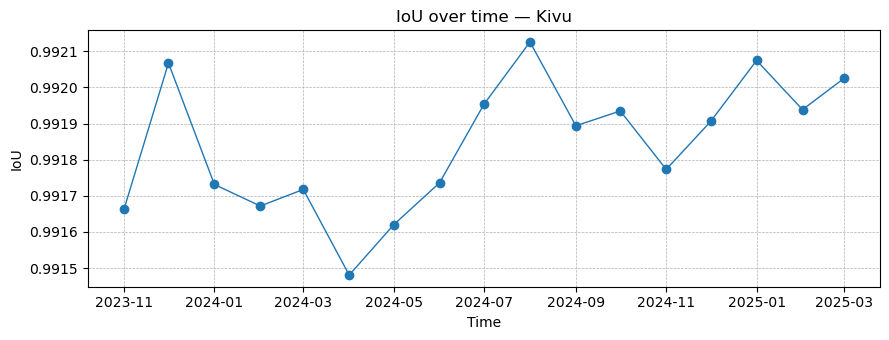

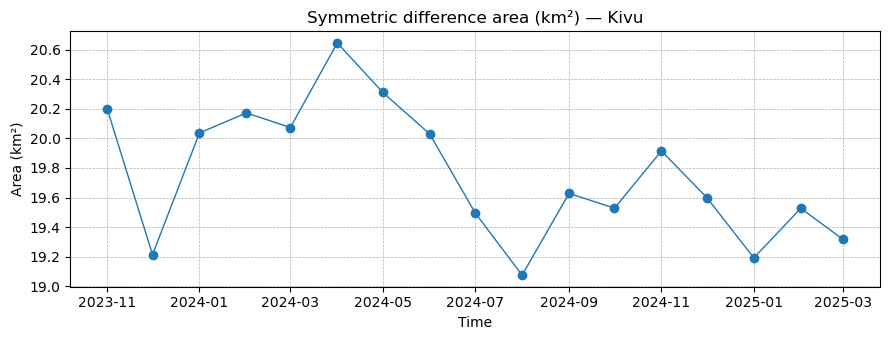

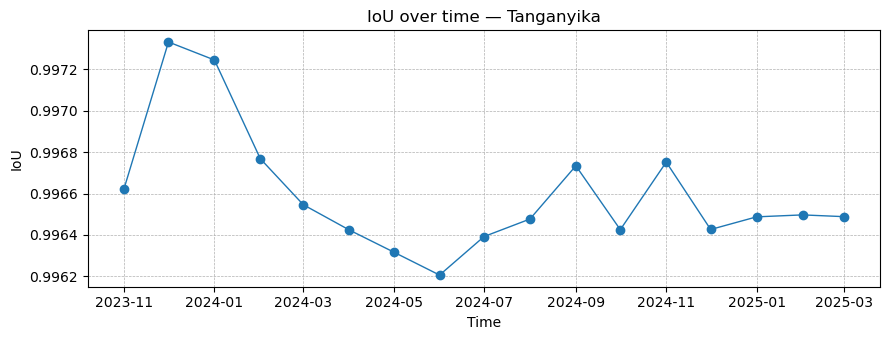

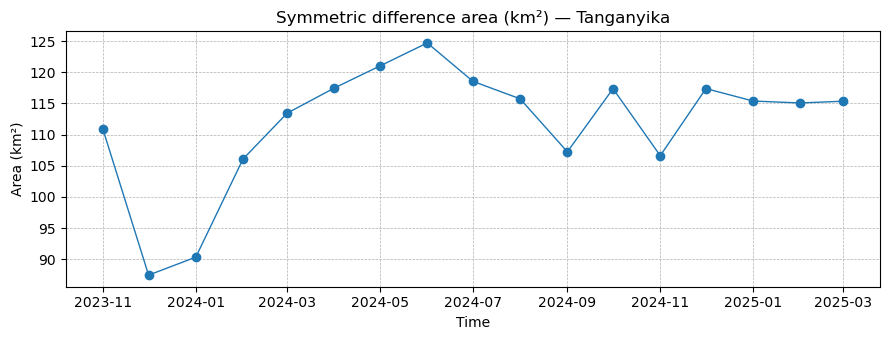


Saved plots → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\plots


In [9]:
# ==============================================================
# PATCH to Block 9 — include Dice in summaries, printing, and keep plots inline
# ==============================================================

# Overall summary per lake (saved as CSV as before)
grp = df.groupby("lake", dropna=True)
summary = grp.agg(
    n=("iou","count"),
    iou_mean=("iou","mean"),
    iou_median=("iou","median"),
    iou_min=("iou","min"),
    iou_max=("iou","max"),
    dice_mean=("dice","mean"),
    precision_mean=("precision","mean"),
    recall_mean=("recall","mean"),
    f1_mean=("f1","mean"),
    symdiff_mean_km2=("symdiff_km2","mean"),
    area_dem_mean_km2=("area_dem_km2","mean"),
    area_gee_mean_km2=("area_gee_km2","mean"),
    boundary_mean_m=("boundary_mean_m","mean"),
    hausdorff_mean_m=("hausdorff_m","mean")
).reset_index()

summary_csv = TABLES_DIR / "iou_summary_by_lake.csv"
summary.to_csv(summary_csv, index=False, encoding="utf-8-sig")
print(f"Saved summary → {summary_csv}")

# Lowest IoU months per lake (saved as CSV as before)
lowest = df.sort_values(["lake","iou"]).groupby("lake", dropna=True).head(5)
lowest_csv = TABLES_DIR / "lowest_iou_top5.csv"
lowest.to_csv(lowest_csv, index=False, encoding="utf-8-sig")
print(f"Saved lowest-IoU months → {lowest_csv}")

# --- human-readable summaries (now include Dice) ---
def _fmt(x, nd=3):
    try: return f"{float(x):.{nd}f}"
    except Exception: return "nan"

print("\n=== OVERALL (all lakes) ===")
overall_valid = df[pd.notna(df["iou"])].copy()
overall_stats = {
    "n": int(overall_valid.shape[0]),
    "iou_mean": overall_valid["iou"].mean(),
    "iou_median": overall_valid["iou"].median(),
    "iou_min": overall_valid["iou"].min(),
    "iou_max": overall_valid["iou"].max(),
    "dice_mean": overall_valid["dice"].mean(),
    "precision_mean": overall_valid["precision"].mean(skipna=True),
    "recall_mean": overall_valid["recall"].mean(skipna=True),
    "f1_mean": overall_valid["f1"].mean(skipna=True),
    "symdiff_mean_km2": overall_valid["symdiff_km2"].mean(skipna=True),
}
print(f"Months analyzed (n):     {overall_stats['n']}")
print(f"IoU: mean={_fmt(overall_stats['iou_mean'])}, median={_fmt(overall_stats['iou_median'])}, "
      f"min={_fmt(overall_stats['iou_min'])}, max={_fmt(overall_stats['iou_max'])}")
print(f"Dice mean={_fmt(overall_stats['dice_mean'])} | "
      f"Precision mean={_fmt(overall_stats['precision_mean'])} | "
      f"Recall mean={_fmt(overall_stats['recall_mean'])} | "
      f"F1 mean={_fmt(overall_stats['f1_mean'])}")
print(f"Symmetric difference area (km²), mean={_fmt(overall_stats['symdiff_mean_km2'])}")

print("\n=== PER-LAKE SUMMARY ===")
for _, row in summary.iterrows():
    lake = row["lake"]
    print(f"\n— {lake} —")
    print(f"  Months analyzed (n): {int(row['n'])}")
    print(f"  IoU:  mean={_fmt(row['iou_mean'])}, median={_fmt(row['iou_median'])}, "
          f"min={_fmt(row['iou_min'])}, max={_fmt(row['iou_max'])}")
    print(f"  Dice: mean={_fmt(row['dice_mean'])}")
    if pd.notna(row['precision_mean']): print(f"  Precision (DEM vs GEE):  mean={_fmt(row['precision_mean'])}")
    if pd.notna(row['recall_mean']):    print(f"  Recall (DEM vs GEE):     mean={_fmt(row['recall_mean'])}")
    if pd.notna(row['f1_mean']):        print(f"  F1 score:                mean={_fmt(row['f1_mean'])}")
    if pd.notna(row['symdiff_mean_km2']): print(f"  Symmetric diff (km²):    mean={_fmt(row['symdiff_mean_km2'])}")
    if pd.notna(row['area_dem_mean_km2']): print(f"  Mean area DEM (km²):     {_fmt(row['area_dem_mean_km2'])}")
    if pd.notna(row['area_gee_mean_km2']): print(f"  Mean area GEE (km²):     {_fmt(row['area_gee_mean_km2'])}")

print("\n=== Lowest IoU months (top 5 per lake) ===")
for lake, sub in lowest.groupby("lake", dropna=True):
    print(f"\n— {lake} —")
    for _, r in sub.iterrows():
        print(f"  {int(r['year'])}-{int(r['month']):02d}: IoU={_fmt(r['iou'])}, Dice={_fmt(r['dice'])}, "
              f"DEM_area={_fmt(r['area_dem_km2'])} km², GEE_area={_fmt(r['area_gee_km2'])} km², "
              f"SymDiff={_fmt(r['symdiff_km2'])} km²")

# Plots: show inline (unchanged) + saved PNGs
if MAKE_PLOTS:
    for lake in df["lake"].dropna().unique():
        sub = df[df["lake"]==lake].copy()
        if sub.empty: continue
        sub["yyyymm"] = pd.to_datetime(sub["year"].astype(str) + "-" + sub["month"].astype(str) + "-01")

        plt.figure(figsize=(9,3.5))
        plt.plot(sub["yyyymm"], sub["iou"], marker="o", linewidth=1)
        plt.title(f"IoU over time — {lake}")
        plt.xlabel("Time"); plt.ylabel("IoU")
        plt.grid(True, linestyle="--", linewidth=0.5)
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f"iou_timeseries_{lake.lower()}.png", dpi=SAVE_PNG_DPI)
        plt.show()

        plt.figure(figsize=(9,3.5))
        plt.plot(sub["yyyymm"], sub["symdiff_km2"], marker="o", linewidth=1)
        plt.title(f"Symmetric difference area (km²) — {lake}")
        plt.xlabel("Time"); plt.ylabel("Area (km²)")
        plt.grid(True, linestyle="--", linewidth=0.5)
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f"symdiff_timeseries_{lake.lower()}.png", dpi=SAVE_PNG_DPI)
        plt.show()

    print(f"\nSaved plots → {PLOTS_DIR}")

In [10]:
# ==============================================================
# 9B) Incremental add-on — compute ONLY boundary metrics and merge into existing CSV
#      (Robust to existing columns; safe to re-run)
# ==============================================================

# 1) Sampling controls for boundary metrics
COMPUTE_BOUNDARY_METRICS = True
BOUNDARY_SAMPLE_EVERY_M = 2000.0  # e.g., 500–2000 m for more detail; larger = faster

# 2) Load the previously saved per-month table
per_month_csv = TABLES_DIR / "iou_per_month.csv"
if not per_month_csv.exists():
    raise FileNotFoundError(f"Expected existing metrics file not found: {per_month_csv}")

df_prev = pd.read_csv(per_month_csv)

# Ensure join keys are clean and of the same dtype
for col in ["year", "month"]:
    df_prev[col] = pd.to_numeric(df_prev[col], errors="coerce").astype("Int64")

# 3) Rebuild (or reuse) working CRS per lake and the (lake,year,month) pairs
dem_idx = find_dem_files()
gee_idx = find_gee_files()

lake_to_workcrs: Dict[str, CRS] = {}
for lake in LAKES_TO_PROCESS:
    lake_dem_any = next((p for (lk,_,_), p in dem_idx.items() if lk==lake), None)
    lake_gee_any = next((p for (lk,_,_), p in gee_idx.items() if lk==lake), None)
    work_crs = choose_work_crs(lake, lake_dem_any, lake_gee_any)
    lake_to_workcrs[lake] = work_crs

pairs = []
for (lake, y, m), dem_path in dem_idx.items():
    if lake not in LAKES_TO_PROCESS:
        continue
    gee_path = gee_idx.get((lake, y, m))
    if not gee_path:
        continue
    if RUN_ONLY_YYYY_MM and f"{y:04d}_{m:02d}" != RUN_ONLY_YYYY_MM:
        continue
    pairs.append((lake, y, m, dem_path, gee_path))

# 4) Compute boundary metrics only
rows_b = []
for lake, y, m, dem_path, gee_path in tqdm(pairs, desc="Boundary-only", unit="pair"):
    work_crs = lake_to_workcrs[lake]
    A = read_single_multipart_polygon(dem_path, work_crs, dissolve=DISSOLVE_INPUTS, fix_invalid=FIX_INVALID)
    B = read_single_multipart_polygon(gee_path, work_crs, dissolve=DISSOLVE_INPUTS, fix_invalid=FIX_INVALID)

    if COMPUTE_BOUNDARY_METRICS:
        bd = boundary_distance_stats(A, B, step_m=BOUNDARY_SAMPLE_EVERY_M)
    else:
        bd = {"boundary_mean_m": np.nan, "boundary_max_m": np.nan, "hausdorff_m": np.nan}

    rows_b.append({"lake": lake, "year": y, "month": m, **bd})

df_b = pd.DataFrame(rows_b)
for col in ["year", "month"]:
    df_b[col] = pd.to_numeric(df_b[col], errors="coerce").astype("Int64")

# 5) Merge safely:
#    - Keep existing columns if new ones are NaN
#    - Overwrite with new values when available
merge_keys = ["lake", "year", "month"]
df_merged = df_prev.merge(df_b, on=merge_keys, how="left", suffixes=("", "_bnd"))

def _coalesce_inplace(df, base_col, new_col):
    if new_col in df.columns:
        if base_col in df.columns:
            df[base_col] = df[new_col].combine_first(df[base_col])
        else:
            df.rename(columns={new_col: base_col}, inplace=True)
        df.drop(columns=[new_col], inplace=True, errors="ignore")

for base in ["boundary_mean_m", "boundary_max_m", "hausdorff_m"]:
    _coalesce_inplace(df_merged, base, f"{base}_bnd")

# 6) Save outputs
df_merged.to_csv(per_month_csv, index=False, encoding="utf-8-sig")
per_month_with_b = TABLES_DIR / "iou_per_month_with_boundary.csv"
df_merged.to_csv(per_month_with_b, index=False, encoding="utf-8-sig")

print(f"Updated per-month table with boundary metrics → {per_month_csv}")
print(f"Also saved a copy → {per_month_with_b}")

# 7) Quick text summary of the newly computed boundary metrics
def _fmt(x, nd=2):
    try: return f"{float(x):.{nd}f}"
    except: return "nan"

print("\nBoundary metrics summary (meters):")
print("Overall mean:",
      " mean_d =", _fmt(df_b["boundary_mean_m"].mean()),
      " max_d =", _fmt(df_b["boundary_max_m"].mean()),
      " hausdorff =", _fmt(df_b["hausdorff_m"].mean()))
for lk, sub in df_b.groupby("lake"):
    print(f" {lk}:",
          " mean_d =", _fmt(sub["boundary_mean_m"].mean()),
          " max_d =", _fmt(sub["boundary_max_m"].mean()),
          " hausdorff =", _fmt(sub["hausdorff_m"].mean()))


Boundary-only: 100%|██████████| 34/34 [1:31:04<00:00, 160.71s/pair]  ﻿


Updated per-month table with boundary metrics → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\tables\iou_per_month.csv
Also saved a copy → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\tables\iou_per_month_with_boundary.csv

Boundary metrics summary (meters):
Overall mean:  mean_d = 88.73  max_d = 8596.50  hausdorff = 8678.82
 Kivu:  mean_d = 110.62  max_d = 12565.47  hausdorff = 12576.08
 Tanganyika:  mean_d = 66.85  max_d = 4627.52  hausdorff = 4781.55


[9C] Will compute per-point distances for 34 lake-month(s).


Distances for hists: 100%|██████████| 34/34 [29:38<00:00, 52.31s/lm] ﻿


[9C] Diagnostic point packages saved → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\diagnostics_points
[9C] Saved per-month distance distribution stats → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\tables\boundary_distance_distributions.csv


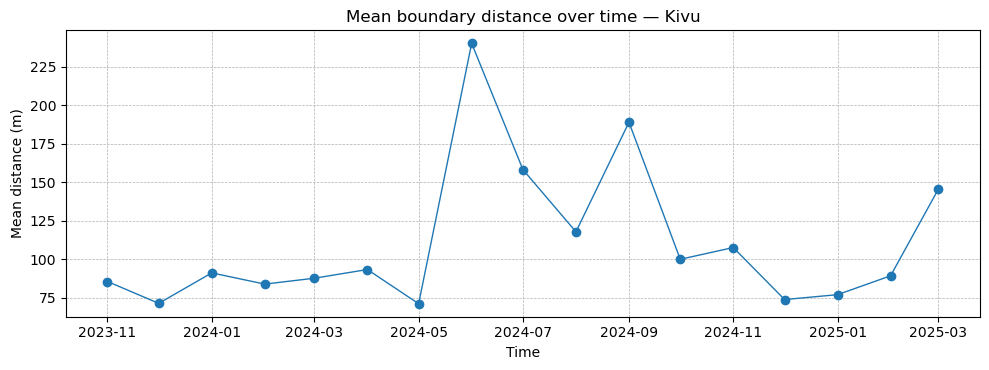

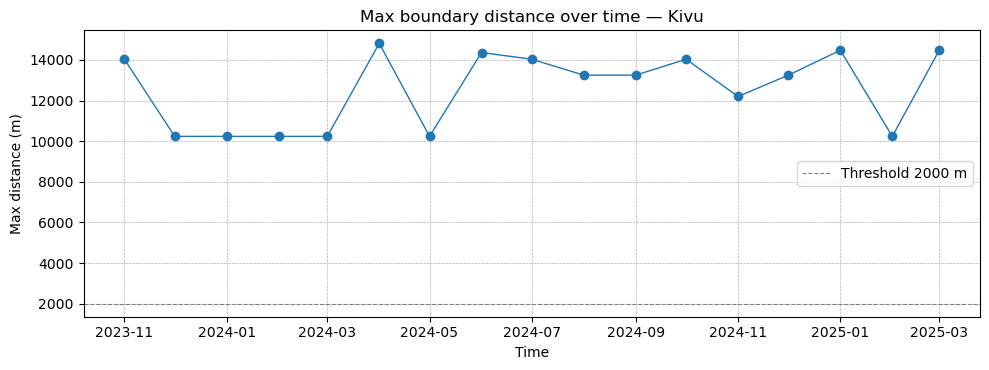

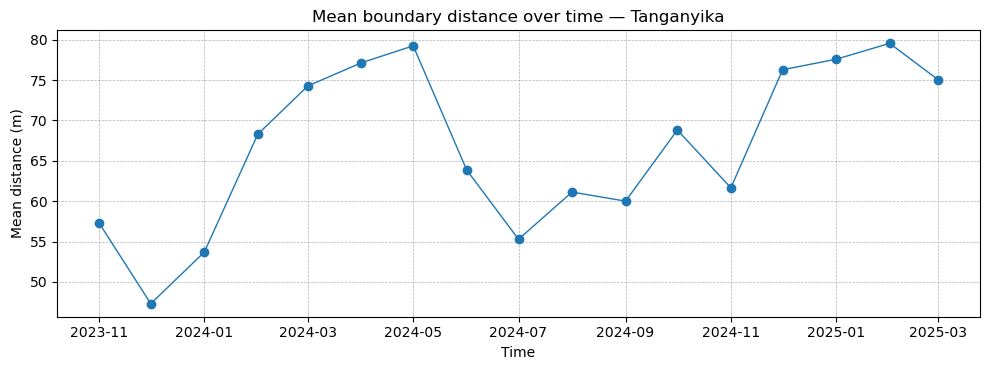

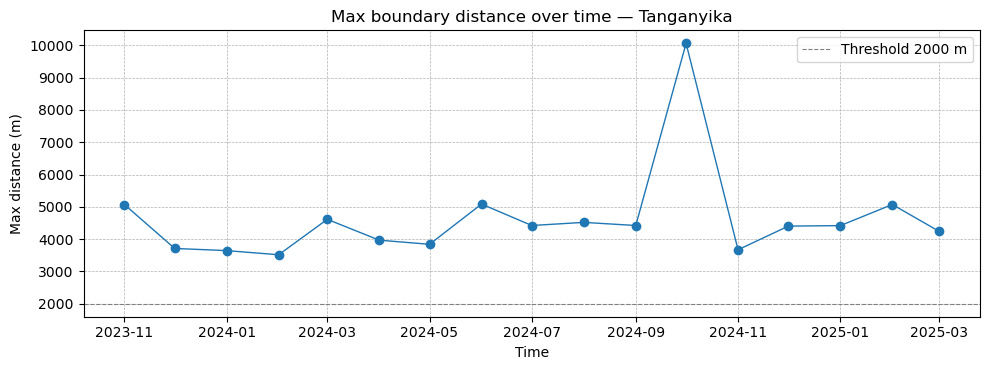

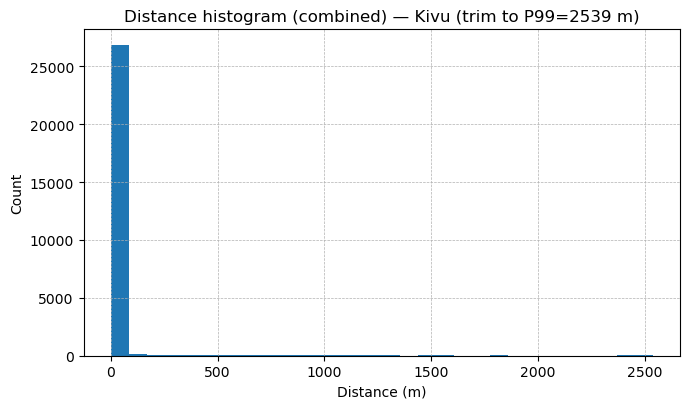

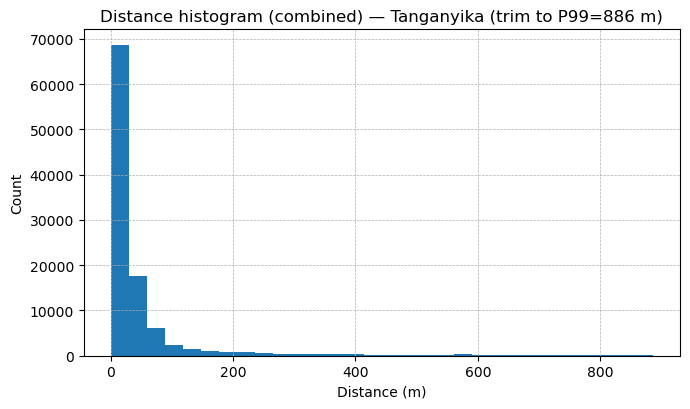

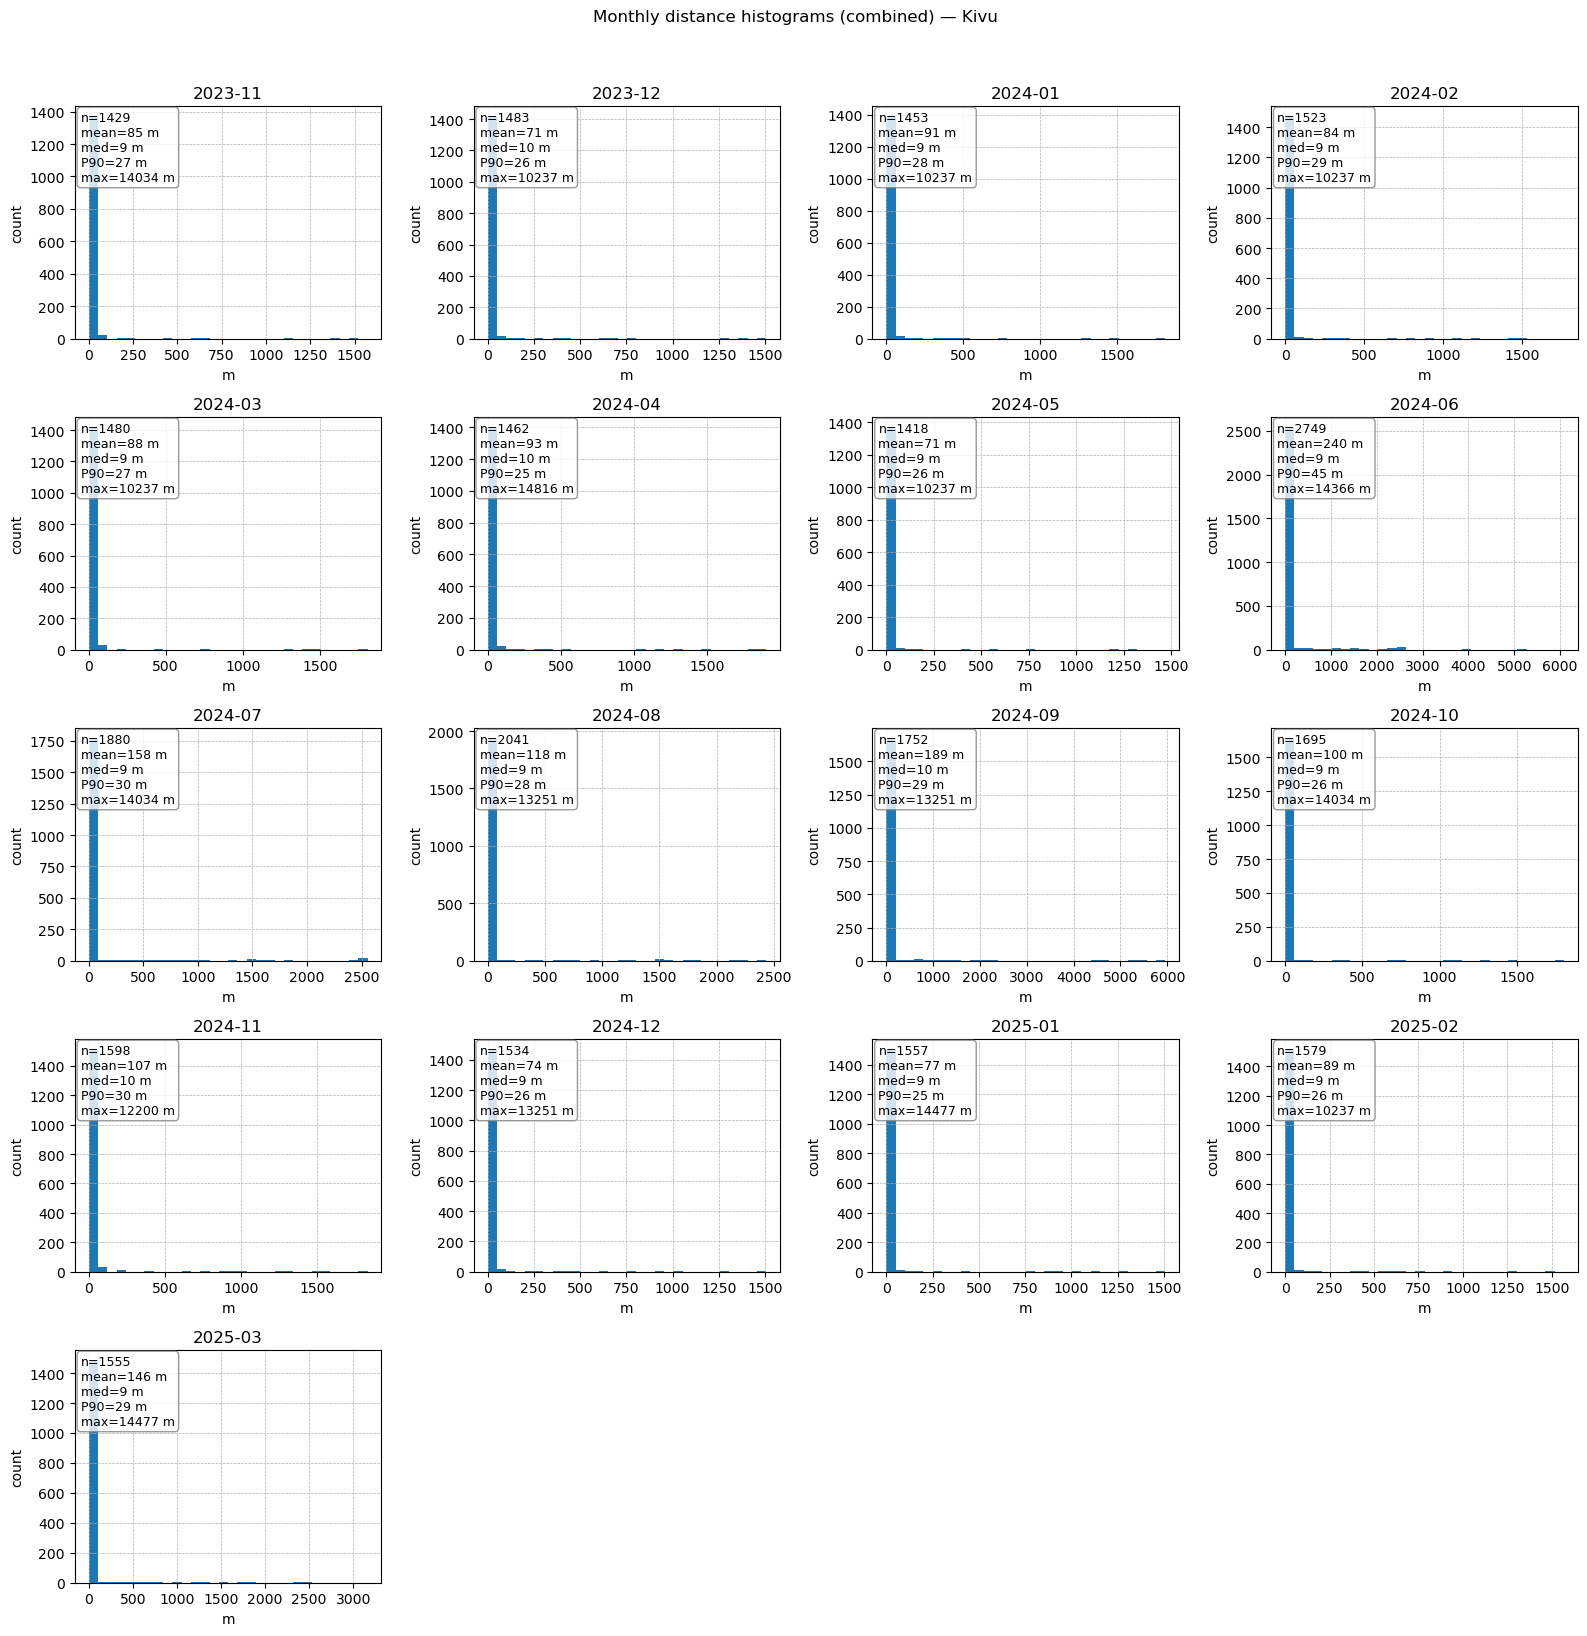

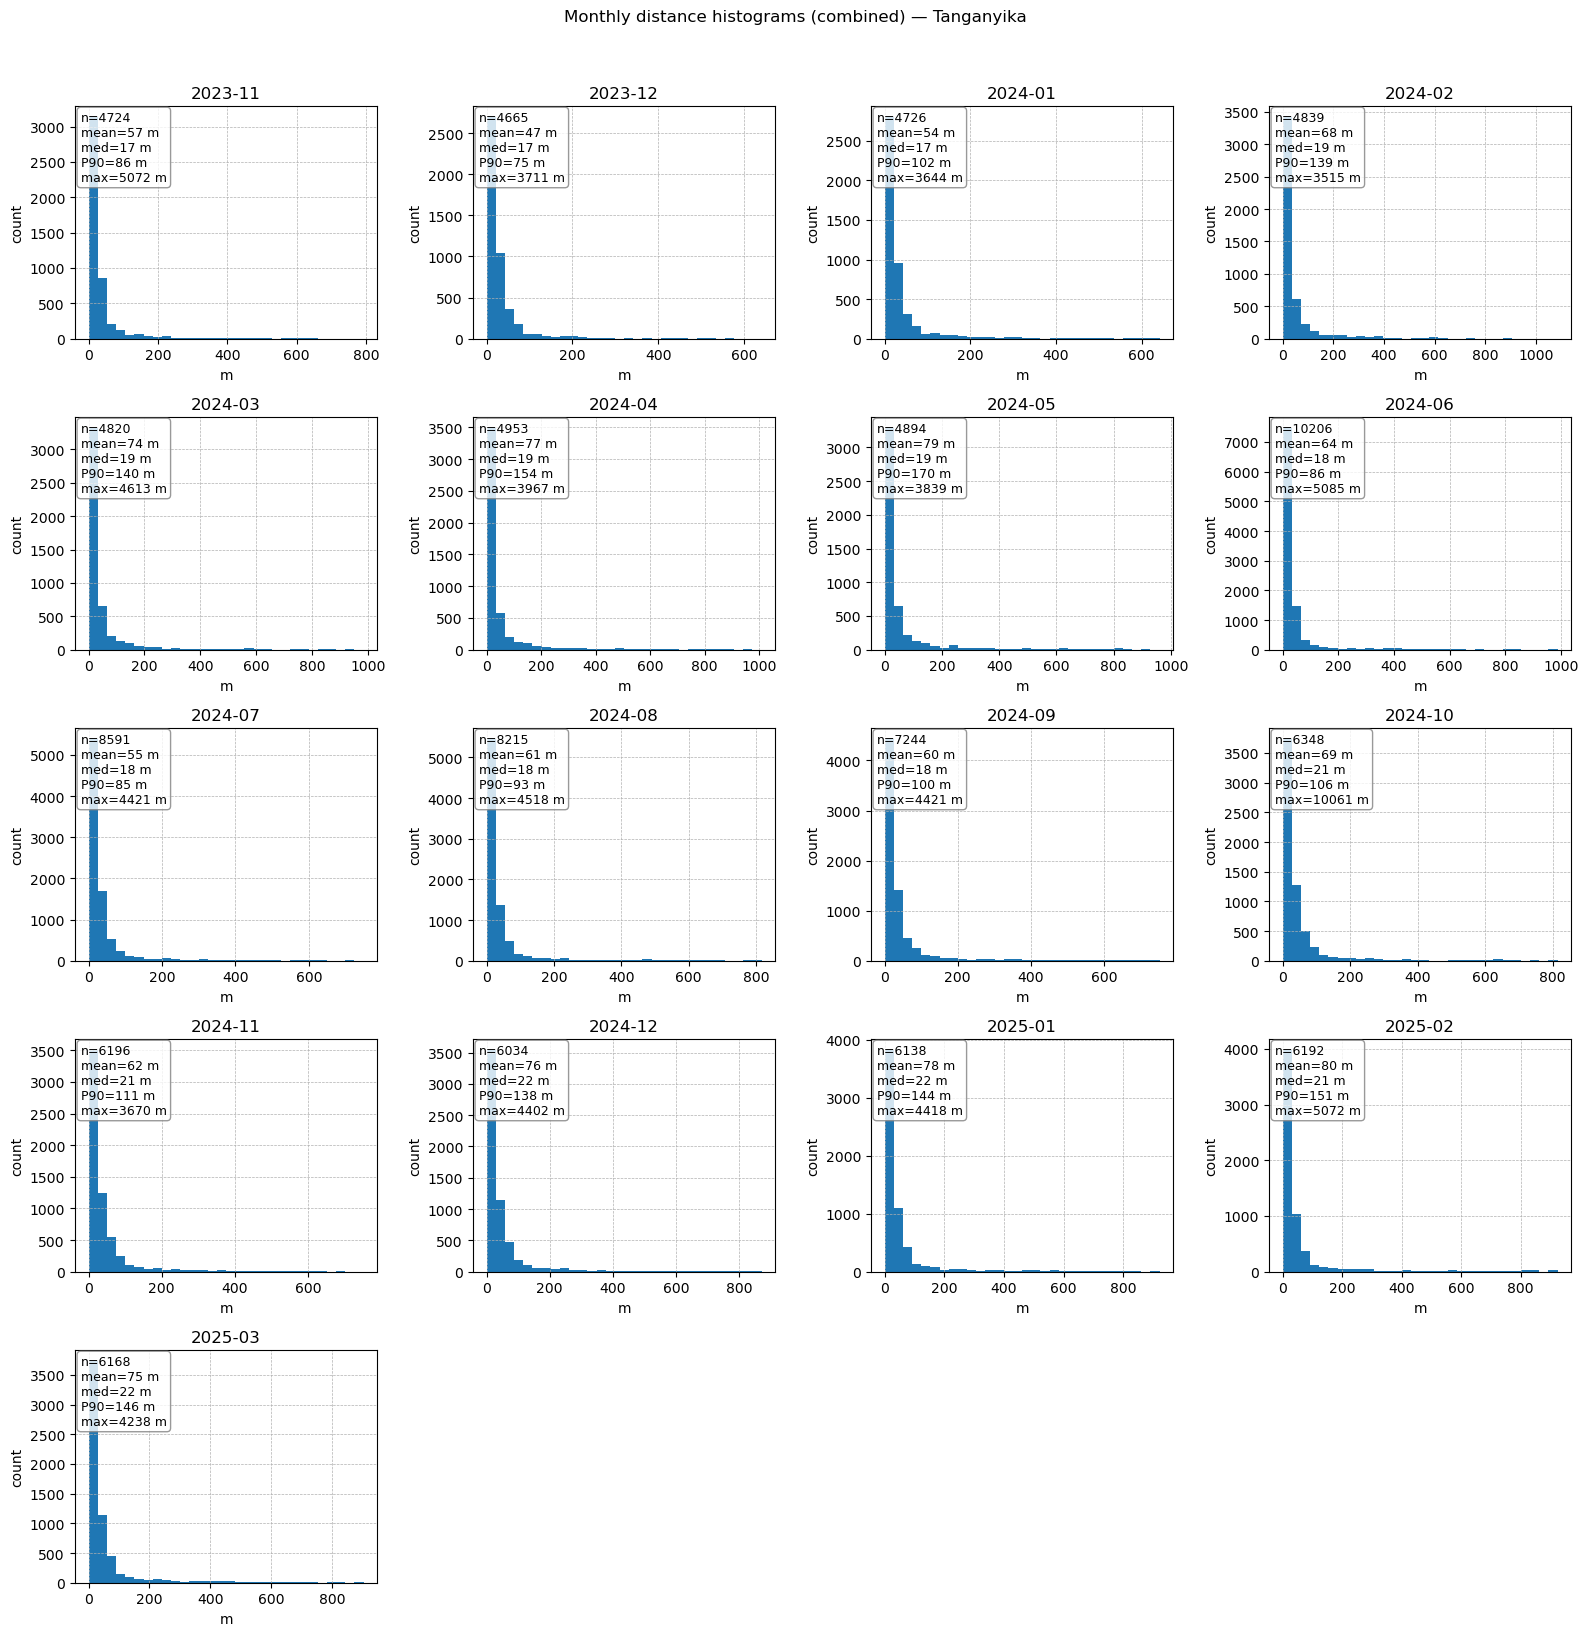

[9C] Plots saved → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\plots


In [11]:
# ==============================================================
# 9C) Boundary metrics — plots, outlier checks, distributions & diagnostic exports (UPDATED)
# ==============================================================

from shapely.ops import nearest_points
from shapely.geometry import Point, LineString, MultiLineString
import math

# ---- Settings for this block ----
# Which months to compute per-point distances for histograms?
HIST_MODE = "ALL"    # "ALL" | "OUTLIERS" | "SINGLE"
SELECT_SINGLE_YYYY_MM = None  # e.g., "2024_07" if HIST_MODE == "SINGLE"

# Outlier logic used both for selection and earlier plots
OUTLIER_MAX_THRESHOLD_M    = 2000.0
MAX_MONTHS_EXPORT_PER_LAKE = 3

# Sampling step along boundaries (meters)
BOUNDARY_SAMPLE_EVERY_M = float(BOUNDARY_SAMPLE_EVERY_M)  # reuse your setting

# Export sampled points and connecting segments (GeoPackage) for selected months
EXPORT_BOUNDARY_POINTS = True

# Plot controls
PLOT_HIST_BINS = 30
SAVE_PNG_DPI   = int(SAVE_PNG_DPI) if "SAVE_PNG_DPI" in globals() else 150

per_month_csv = TABLES_DIR / "iou_per_month.csv"
df_all = pd.read_csv(per_month_csv)
for col in ["year","month"]:
    df_all[col] = pd.to_numeric(df_all[col], errors="coerce").astype("Int64")

# ---------- helpers ----------
def _boundary_lines(geom: sgeom.base.BaseGeometry) -> sgeom.base.BaseGeometry:
    """Return outer boundary MultiLineString/LineString (ignore holes)."""
    if geom.is_empty:
        return sgeom.MultiLineString([])
    polys = list(geom.geoms) if isinstance(geom, sgeom.MultiPolygon) else [geom]
    lines = [p.exterior for p in polys if isinstance(p, sgeom.Polygon)]
    if not lines:
        return sgeom.MultiLineString([])
    return unary_union(lines)

def _densify_line(line: LineString, step_m: float) -> np.ndarray:
    if step_m <= 0:
        return np.asarray(line.coords)
    length = line.length
    n = max(2, int(math.ceil(length/step_m)) + 1)
    dists = np.linspace(0.0, float(length), n)
    pts = [line.interpolate(d) for d in dists]
    return np.array([(p.x, p.y) for p in pts], dtype="float64")

def _sample_boundary_points(geom: sgeom.base.BaseGeometry, step_m: float) -> np.ndarray:
    b = _boundary_lines(geom)
    if isinstance(b, MultiLineString):
        arrs = []
        for ls in b.geoms:
            if ls.length > 0:
                arrs.append(_densify_line(ls, step_m))
        return np.vstack(arrs) if arrs else np.empty((0,2))
    elif isinstance(b, LineString):
        return _densify_line(b, step_m) if b.length > 0 else np.empty((0,2))
    else:
        return np.empty((0,2))

def compute_pair_dist_arrays(A: sgeom.base.BaseGeometry, B: sgeom.base.BaseGeometry, step_m: float):
    """Return (DEM→GEE distances array, GEE→DEM distances array) in meters."""
    if A is None or B is None or A.is_empty or B.is_empty:
        return np.empty(0), np.empty(0)
    Ab = _boundary_lines(A)
    Bb = _boundary_lines(B)
    Apts = _sample_boundary_points(A, step_m)
    Bpts = _sample_boundary_points(B, step_m)

    dA = []
    for x,y in Apts:
        P = Point(x,y)
        _, R = nearest_points(P, Bb)
        dA.append(P.distance(R))
    dB = []
    for x,y in Bpts:
        P = Point(x,y)
        _, R = nearest_points(P, Ab)
        dB.append(P.distance(R))
    return np.array(dA, dtype="float64"), np.array(dB, dtype="float64")

def ym_label(y, m): 
    return f"{int(y):04d}_{int(m):02d}"

# ---------- selection of months for per-point histograms/exports ----------
sel = []
if HIST_MODE.upper() == "SINGLE" and SELECT_SINGLE_YYYY_MM:
    yy, mm = map(int, SELECT_SINGLE_YYYY_MM.split("_"))
    sub = df_all[(df_all["year"]==yy) & (df_all["month"]==mm)]
    for _, r in sub.iterrows():
        sel.append((r["lake"], int(r["year"]), int(r["month"])))
elif HIST_MODE.upper() == "OUTLIERS":
    for lake, sub in df_all.groupby("lake", dropna=True):
        sub2 = sub[sub["boundary_max_m"] > OUTLIER_MAX_THRESHOLD_M].sort_values("boundary_max_m", ascending=False)
        sub2 = sub2.head(MAX_MONTHS_EXPORT_PER_LAKE)
        for _, r in sub2.iterrows():
            sel.append((lake, int(r["year"]), int(r["month"])))
else:  # "ALL"
    for _, r in df_all.iterrows():
        sel.append((r["lake"], int(r["year"]), int(r["month"])))

sel = list(dict.fromkeys(sel))  # unique
print(f"[9C] Will compute per-point distances for {len(sel)} lake-month(s).")

# ---------- prep geometry index & work CRS ----------
dem_idx = find_dem_files()
gee_idx = find_gee_files()
lake_to_workcrs = {}
for lake in df_all["lake"].dropna().unique():
    lake_dem_any = next((p for (lk,_,_), p in dem_idx.items() if lk==lake), None)
    lake_gee_any = next((p for (lk,_,_), p in gee_idx.items() if lk==lake), None)
    lake_to_workcrs[lake] = choose_work_crs(lake, lake_dem_any, lake_gee_any)

# ---------- main loop: compute arrays, optional export points, collect stats ----------
DIAG_DIR = IOU_ROOT / "diagnostics_points"
if EXPORT_BOUNDARY_POINTS:
    DIAG_DIR.mkdir(parents=True, exist_ok=True)

per_month_stats = []   # for CSV summary of distributions
lake_to_all_dists = {} # aggregate per lake (combined directions)

for lake, y, m in tqdm(sel, desc="Distances for hists", unit="lm"):
    dem_path = dem_idx.get((lake, y, m))
    gee_path = gee_idx.get((lake, y, m))
    if dem_path is None or gee_path is None:
        continue

    work_crs = lake_to_workcrs[lake]
    A = read_single_multipart_polygon(dem_path, work_crs, dissolve=DISSOLVE_INPUTS, fix_invalid=FIX_INVALID)  # DEM
    B = read_single_multipart_polygon(gee_path, work_crs, dissolve=DISSOLVE_INPUTS, fix_invalid=FIX_INVALID)  # GEE
    if A is None or B is None or A.is_empty or B.is_empty:
        continue

    dA, dB = compute_pair_dist_arrays(A, B, step_m=BOUNDARY_SAMPLE_EVERY_M)
    dC = np.concatenate([dA, dB]) if dA.size or dB.size else np.empty(0)

    # stats for this month
    def _s(x):
        if x.size==0: 
            return dict(n=0, mean=np.nan, median=np.nan, p90=np.nan, p95=np.nan, max=np.nan)
        return dict(n=int(x.size),
                    mean=float(np.mean(x)),
                    median=float(np.median(x)),
                    p90=float(np.percentile(x, 90)),
                    p95=float(np.percentile(x, 95)),
                    max=float(np.max(x)))
    sA, sB, sC = _s(dA), _s(dB), _s(dC)
    per_month_stats.append({
        "lake":lake, "year":y, "month":m, "yyyymm": ym_label(y,m),
        "mode":"DEM2GEE", **sA
    })
    per_month_stats.append({
        "lake":lake, "year":y, "month":m, "yyyymm": ym_label(y,m),
        "mode":"GEE2DEM", **sB
    })
    per_month_stats.append({
        "lake":lake, "year":y, "month":m, "yyyymm": ym_label(y,m),
        "mode":"COMBINED", **sC
    })

    # aggregate by lake (combined)
    lake_to_all_dists.setdefault(lake, []).append(dC)

    # optional export of points + connectors (only for selected months)
    if EXPORT_BOUNDARY_POINTS:
        # build points and connecting segments for COMBINED role to visualize extremes
        Ab = _boundary_lines(A); Bb = _boundary_lines(B)
        Apts = _sample_boundary_points(A, BOUNDARY_SAMPLE_EVERY_M)
        Bpts = _sample_boundary_points(B, BOUNDARY_SAMPLE_EVERY_M)

        rows_dem, rows_gee = [], []
        for x,y_ in Apts:
            P = Point(x,y_)
            _, R = nearest_points(P, Bb)
            d = P.distance(R)
            rows_dem.append({"lake":lake, "year":int(y), "month":int(m),
                             "role":"DEM2GEE", "dist_m":float(d),
                             "px":float(P.x), "py":float(P.y),
                             "nx":float(R.x), "ny":float(R.y)})
        for x,y_ in Bpts:
            P = Point(x,y_)
            _, R = nearest_points(P, Ab)
            d = P.distance(R)
            rows_gee.append({"lake":lake, "year":int(y), "month":int(m),
                             "role":"GEE2DEM", "dist_m":float(d),
                             "px":float(P.x), "py":float(P.y),
                             "nx":float(R.x), "ny":float(R.y)})

        gdf_dem = gpd.GeoDataFrame(rows_dem,
                                   geometry=[Point(r["px"], r["py"]) for r in rows_dem],
                                   crs=work_crs)
        gdf_gee = gpd.GeoDataFrame(rows_gee,
                                   geometry=[Point(r["px"], r["py"]) for r in rows_gee],
                                   crs=work_crs)

        segs_dem = [sgeom.LineString([(r["px"], r["py"]), (r["nx"], r["ny"])]) for r in rows_dem]
        segs_gee = [sgeom.LineString([(r["px"], r["py"]), (r["nx"], r["ny"])]) for r in rows_gee]
        gdf_seg_dem = gpd.GeoDataFrame({"lake":lake, "year":int(y), "month":int(m),
                                        "role":"DEM2GEE", "dist_m":[r["dist_m"] for r in rows_dem]},
                                        geometry=segs_dem, crs=work_crs)
        gdf_seg_gee = gpd.GeoDataFrame({"lake":lake, "year":int(y), "month":int(m),
                                        "role":"GEE2DEM", "dist_m":[r["dist_m"] for r in rows_gee]},
                                        geometry=segs_gee, crs=work_crs)

        gpkg_path = DIAG_DIR / f"boundary_diag_{lake}_{y:04d}_{m:02d}.gpkg"
        if gpkg_path.exists():
            gpkg_path.unlink()
        gdf_dem.to_file(gpkg_path, layer="dem2gee_pts", driver="GPKG")
        gdf_gee.to_file(gpkg_path, layer="gee2dem_pts", driver="GPKG")
        gdf_seg_dem.to_file(gpkg_path, layer="dem2gee_segments", driver="GPKG")
        gdf_seg_gee.to_file(gpkg_path, layer="gee2dem_segments", driver="GPKG")

if EXPORT_BOUNDARY_POINTS:
    print(f"[9C] Diagnostic point packages saved → {DIAG_DIR}")

# ---------- save per-month distribution stats ----------
df_dist = pd.DataFrame(per_month_stats)
dist_csv = TABLES_DIR / "boundary_distance_distributions.csv"
df_dist.to_csv(dist_csv, index=False, encoding="utf-8-sig")
print(f"[9C] Saved per-month distance distribution stats → {dist_csv}")

# ---------- PLOTS ----------
# 1) Time series (separate plots for mean and max)
if MAKE_PLOTS:
    for lake, sub in df_all.groupby("lake", dropna=True):
        sub = sub.copy()
        sub["yyyymm"] = pd.to_datetime(sub["year"].astype(str) + "-" + sub["month"].astype(str) + "-01")

        # Mean distances plot
        plt.figure(figsize=(10,3.8))
        plt.plot(sub["yyyymm"], sub["boundary_mean_m"], marker="o", linewidth=1)
        plt.title(f"Mean boundary distance over time — {lake}")
        plt.xlabel("Time"); plt.ylabel("Mean distance (m)")
        plt.grid(True, linestyle="--", linewidth=0.5)
        plt.tight_layout()
        out1 = PLOTS_DIR / f"boundary_mean_timeseries_{lake.lower()}.png"
        plt.savefig(out1, dpi=SAVE_PNG_DPI)
        plt.show()

        # Max distances plot
        plt.figure(figsize=(10,3.8))
        plt.plot(sub["yyyymm"], sub["boundary_max_m"], marker="o", linewidth=1)
        plt.axhline(OUTLIER_MAX_THRESHOLD_M, color="gray", linestyle="--", linewidth=0.8,
                    label=f"Threshold {OUTLIER_MAX_THRESHOLD_M:.0f} m")
        plt.title(f"Max boundary distance over time — {lake}")
        plt.xlabel("Time"); plt.ylabel("Max distance (m)")
        plt.grid(True, linestyle="--", linewidth=0.5)
        plt.legend()
        plt.tight_layout()
        out2 = PLOTS_DIR / f"boundary_max_timeseries_{lake.lower()}.png"
        plt.savefig(out2, dpi=SAVE_PNG_DPI)
        plt.show()

# 2) Overall histograms per lake (combined directions, selected months)
if MAKE_PLOTS and lake_to_all_dists:
    for lake, arrays in lake_to_all_dists.items():
        if len(arrays)==0:
            continue
        all_d = np.concatenate([a for a in arrays if a.size])
        if all_d.size == 0:
            continue
        p99 = np.percentile(all_d, 99)
        plt.figure(figsize=(7,4.2))
        plt.hist(all_d, bins=PLOT_HIST_BINS, range=(0, p99))  # trim to P99 to avoid one extreme dominating
        plt.title(f"Distance histogram (combined) — {lake} (trim to P99={p99:.0f} m)")
        plt.xlabel("Distance (m)"); plt.ylabel("Count")
        plt.grid(True, linestyle="--", linewidth=0.5)
        plt.tight_layout()
        out = PLOTS_DIR / f"boundary_hist_overall_{lake.lower()}.png"
        plt.savefig(out, dpi=SAVE_PNG_DPI)
        plt.show()

# 3) Monthly grids per lake (combined directions) with stats box
if MAKE_PLOTS and not df_dist.empty:
    for lake in df_dist["lake"].dropna().unique():
        sub_stats = df_dist[(df_dist["lake"]==lake) & (df_dist["mode"]=="COMBINED")].copy()
        # Build ordering by time
        sub_stats["dt"] = pd.to_datetime(sub_stats["year"].astype(str) + "-" + sub_stats["month"].astype(str) + "-01")
        sub_stats = sub_stats.sort_values("dt")

        # For distances, we need to recompute arrays from lake_to_all_dists per-month; build a lookup:
        per_month_arrays = {}
        for lm in sel:
            lk, y, m = lm
            if lk != lake: 
                continue
            # recompute here (ensures availability even if HIST_MODE filtered earlier)
            dem_p = dem_idx.get((lk, y, m)); gee_p = gee_idx.get((lk, y, m))
            if dem_p is None or gee_p is None: 
                continue
            work_crs = lake_to_workcrs[lk]
            A = read_single_multipart_polygon(dem_p, work_crs, dissolve=DISSOLVE_INPUTS, fix_invalid=FIX_INVALID)
            B = read_single_multipart_polygon(gee_p, work_crs, dissolve=DISSOLVE_INPUTS, fix_invalid=FIX_INVALID)
            if A is None or B is None or A.is_empty or B.is_empty:
                continue
            dA, dB = compute_pair_dist_arrays(A, B, step_m=BOUNDARY_SAMPLE_EVERY_M)
            dC = np.concatenate([dA, dB]) if dA.size or dB.size else np.empty(0)
            per_month_arrays[(y,m)] = dC

        if len(per_month_arrays)==0:
            continue

        N = len(sub_stats)
        ncols = 4
        nrows = int(math.ceil(N / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.0, nrows*3.2), squeeze=False)
        axes = axes.ravel()

        for i, (_, row) in enumerate(sub_stats.iterrows()):
            ax = axes[i]
            key = (int(row["year"]), int(row["month"]))
            arr = per_month_arrays.get(key, np.empty(0))
            if arr.size > 0:
                rmax = np.percentile(arr, 99)
                ax.hist(arr, bins=PLOT_HIST_BINS, range=(0, rmax))
                ax.set_title(f'{int(row["year"])}-{int(row["month"]):02d}')
                ax.set_xlabel("m"); ax.set_ylabel("count")
                ax.grid(True, linestyle="--", linewidth=0.5)
                # stats box
                txt = (f'n={int(row["n"])}\n'
                       f'mean={row["mean"]:.0f} m\n'
                       f'med={row["median"]:.0f} m\n'
                       f'P90={row["p90"]:.0f} m\n'
                       f'max={row["max"]:.0f} m')
                ax.text(0.02, 0.98, txt, transform=ax.transAxes, va="top", ha="left",
                        bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8), fontsize=9)
            else:
                ax.text(0.5, 0.5, "no data", ha="center", va="center")
                ax.set_title(f'{int(row["year"])}-{int(row["month"]):02d}')
                ax.set_xticks([]); ax.set_yticks([])

        # Blank remaining subplots
        for j in range(i+1, nrows*ncols):
            axes[j].axis("off")

        plt.suptitle(f"Monthly distance histograms (combined) — {lake}", y=1.02)
        plt.tight_layout()
        out = PLOTS_DIR / f"boundary_hist_monthly_{lake.lower()}.png"
        plt.savefig(out, dpi=SAVE_PNG_DPI, bbox_inches="tight")
        plt.show()

print(f"[9C] Plots saved → {PLOTS_DIR}")


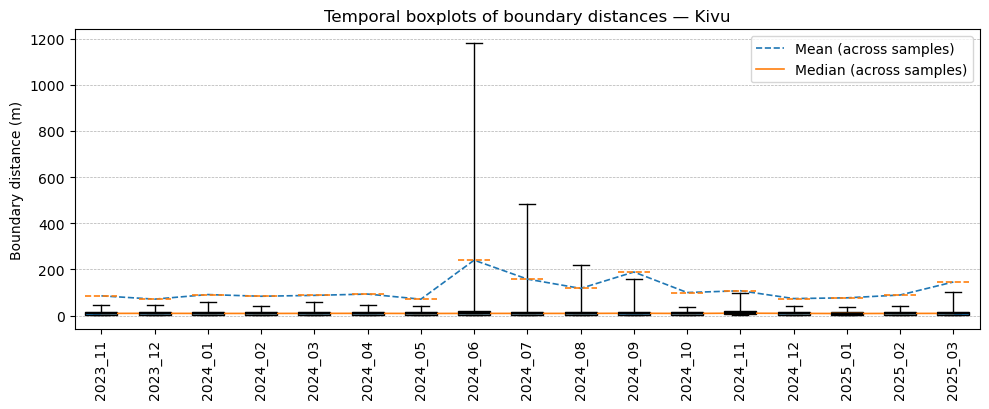

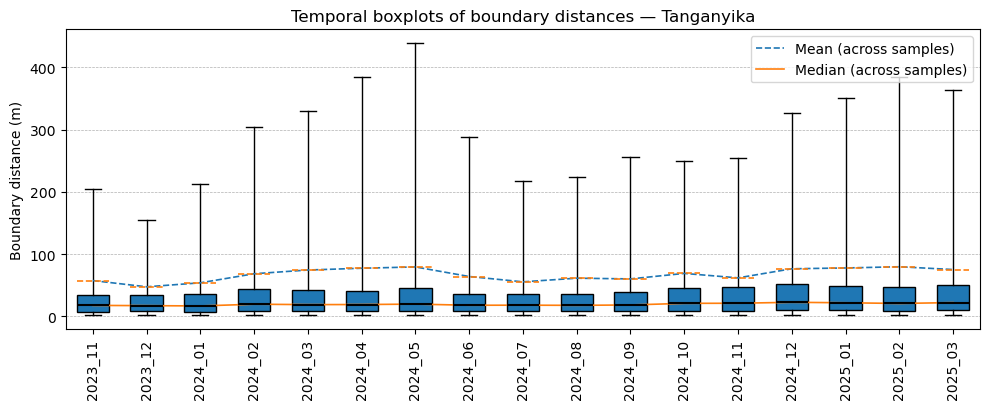

Temporal boxplots saved to: C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\plots


In [12]:
# ==============================================================
# 9C-BOX) Temporal boxplots of boundary distances per lake & month
# ==============================================================

# --- Settings ---
BOX_MODE = "ALL"            # "ALL" | "SAME_AS_HIST" | "SINGLE"
BOX_SINGLE_YYYY_MM = None   # e.g., "2024_07" if BOX_MODE == "SINGLE"
BOX_MAX_POINTS_PER_MONTH = 20000  # downsample if a month has more than this many samples
BOX_RANDOM_SEED = 0               # for reproducible downsampling

# Reuse selections & helpers from 9C if available; otherwise define minimal fallbacks
rng = np.random.default_rng(BOX_RANDOM_SEED)

def _ym_label(y, m): return f"{int(y):04d}_{int(m):02d}"

# Source of months to plot
def _months_for_box(lake):
    if BOX_MODE.upper() == "SINGLE" and BOX_SINGLE_YYYY_MM:
        y, m = map(int, BOX_SINGLE_YYYY_MM.split("_"))
        return [(y, m)]
    elif BOX_MODE.upper() == "SAME_AS_HIST" and 'sel' in globals():
        return sorted([(y, m) for (lk, y, m) in sel if lk == lake])
    else:  # ALL months present in df_all for this lake
        sub = df_all[df_all["lake"] == lake][["year","month"]].dropna().astype(int).drop_duplicates()
        return sorted([(int(r.year), int(r.month)) for r in sub.itertuples(index=False)])

# Build (or reuse) indices and work CRS per lake
if 'dem_idx' not in globals() or 'gee_idx' not in globals():
    dem_idx = find_dem_files()
    gee_idx = find_gee_files()

if 'lake_to_workcrs' not in globals():
    lake_to_workcrs = {}
    for lake in df_all["lake"].dropna().unique():
        lake_dem_any = next((p for (lk,_,_), p in dem_idx.items() if lk==lake), None)
        lake_gee_any = next((p for (lk,_,_), p in gee_idx.items() if lk==lake), None)
        lake_to_workcrs[lake] = choose_work_crs(lake, lake_dem_any, lake_gee_any)

# Compute arrays -> make boxplot per lake
for lake in df_all["lake"].dropna().unique():
    months = _months_for_box(lake)
    if not months:
        continue

    # Prepare data containers
    series = []   # list of np.arrays (combined distances per month)
    labels = []   # "YYYY_MM"
    means  = []   # per-month mean
    medians= []   # per-month median

    work_crs = lake_to_workcrs[lake]

    for (y, m) in months:
        dem_path = dem_idx.get((lake, y, m))
        gee_path = gee_idx.get((lake, y, m))
        if dem_path is None or gee_path is None:
            continue

        # read geometries
        A = read_single_multipart_polygon(dem_path, work_crs, dissolve=DISSOLVE_INPUTS, fix_invalid=FIX_INVALID)  # DEM
        B = read_single_multipart_polygon(gee_path, work_crs, dissolve=DISSOLVE_TO_SINGLE if 'DISSOLVE_TO_SINGLE' in globals() else True, 
                                          fix_invalid=FIX_INVALID)  # GEE
        if A is None or B is None or A.is_empty or B.is_empty:
            continue

        # compute distances (combined directions), reuse helper from 9C
        dA, dB = compute_pair_dist_arrays(A, B, step_m=BOUNDARY_SAMPLE_EVERY_M)
        dC = np.concatenate([dA, dB]) if dA.size or dB.size else np.empty(0)
        if dC.size == 0:
            continue

        # optional downsample to keep plots legible
        if dC.size > BOX_MAX_POINTS_PER_MONTH:
            idx = rng.choice(dC.size, size=BOX_MAX_POINTS_PER_MONTH, replace=False)
            dC = dC[idx]

        series.append(dC)
        labels.append(_ym_label(y, m))
        means.append(float(np.mean(dC)))
        medians.append(float(np.median(dC)))

    if not series:
        continue

    # Create boxplot (robust whiskers, hide fliers)
    fig, ax = plt.subplots(figsize=(max(10, 0.45*len(series)), 4.2))
    bp = ax.boxplot(
        series,
        whis=(5,95),          # robust whiskers (5th–95th percentile)
        showfliers=False,     # hide extreme fliers to avoid squashing
        patch_artist=True,
        showmeans=True,
        meanline=True,
        widths=0.6,
        medianprops=dict(color="black", linewidth=1.5),
        meanprops=dict(color="tab:orange", linestyle="--", linewidth=1.2)
    )

    ax.set_xticks(range(1, len(labels)+1))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_ylabel("Boundary distance (m)")
    ax.set_title(f"Temporal boxplots of boundary distances — {lake}")
    ax.grid(True, linestyle="--", linewidth=0.5, axis="y")

    # Overlay mean (orange dashed) & median (black solid) as lines across months
    x = np.arange(1, len(series)+1)
    ax.plot(x, means, linestyle="--", linewidth=1.2, label="Mean (across samples)")
    ax.plot(x, medians, linestyle="-", linewidth=1.2, label="Median (across samples)")
    ax.legend(loc="upper right")

    plt.tight_layout()
    out = PLOTS_DIR / f"boundary_boxplot_monthly_{lake.lower()}.png"
    plt.savefig(out, dpi=SAVE_PNG_DPI, bbox_inches="tight")
    plt.show()

print("Temporal boxplots saved to:", PLOTS_DIR)


Shoreline IoU: 100%|██████████| 34/34 [6:33:34<00:00, 694.55s/pair]    ﻿


Saved shoreline-band IoU → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\tables\shoreline_iou_band_2000m.csv


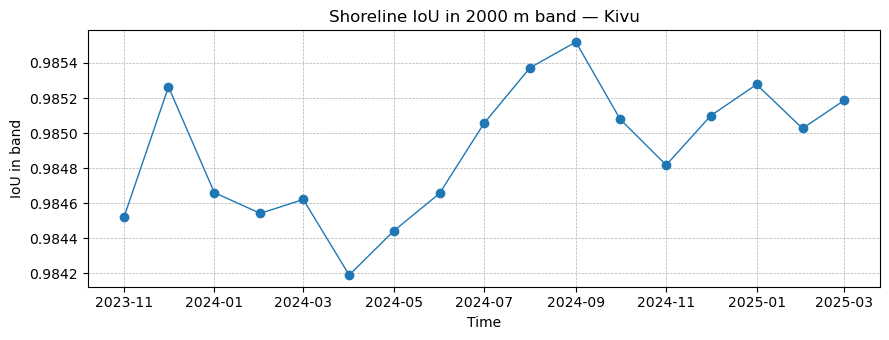

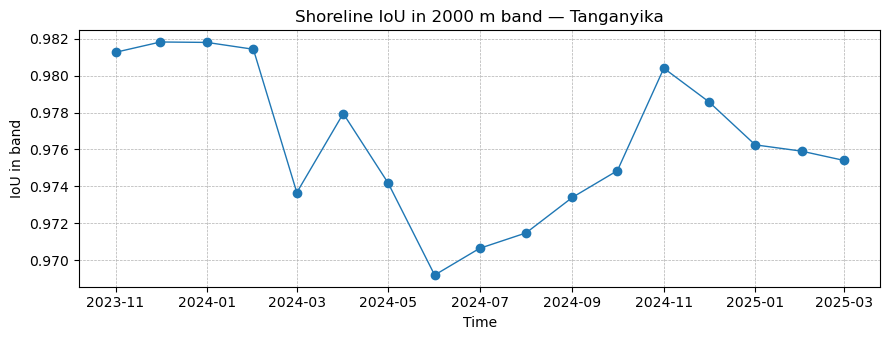

In [13]:
# ==============================================================
# 10) Shoreline-focused metrics — IoU in a boundary band
# ==============================================================

# Settings
SHORE_REF = "GEE"           # "GEE" (reference shoreline) or "DEM"
BAND_HALF_WIDTH_M = 2000.0  # e.g., 2 km band around shoreline

rows_shore = []

for lake, y, m, dem_path, gee_path in tqdm(pairs, desc="Shoreline IoU", unit="pair"):
    work_crs = lake_to_workcrs[lake]
    A = read_single_multipart_polygon(dem_path, work_crs, dissolve=DISSOLVE_INPUTS, fix_invalid=FIX_INVALID)  # DEM
    B = read_single_multipart_polygon(gee_path, work_crs, dissolve=DISSOLVE_INPUTS, fix_invalid=FIX_INVALID)  # GEE
    if A is None or B is None or A.is_empty or B.is_empty:
        continue

    ref = B if SHORE_REF.upper()=="GEE" else A
    # Build a thin band around shoreline: buffer(+d) minus buffer(-d)
    band_outer = ref.buffer(BAND_HALF_WIDTH_M)
    band_inner = ref.buffer(-BAND_HALF_WIDTH_M)
    band = band_outer.difference(band_inner)
    if band.is_empty:
        continue

    # Restrict polygons to the band
    Ab = A.intersection(band)
    Bb = B.intersection(band)

    # IoU within the band
    inter = Ab.intersection(Bb)
    union = Ab.union(Bb)
    aI = area_km2(inter); aU = area_km2(union); iou_band = (aI/aU) if aU>0 else np.nan

    rows_shore.append({"lake":lake, "year":y, "month":m,
                       "band_width_m": BAND_HALF_WIDTH_M,
                       "iou_band": iou_band,
                       "area_band_km2": area_km2(band),
                       "A_in_band_km2": area_km2(Ab),
                       "B_in_band_km2": area_km2(Bb)})

df_shore = pd.DataFrame(rows_shore).sort_values(["lake","year","month"])
shore_csv = TABLES_DIR / f"shoreline_iou_band_{int(BAND_HALF_WIDTH_M)}m.csv"
df_shore.to_csv(shore_csv, index=False, encoding="utf-8-sig")
print(f"Saved shoreline-band IoU → {shore_csv}")

# Plot
if MAKE_PLOTS and not df_shore.empty:
    for lake, sub in df_shore.groupby("lake"):
        sub = sub.copy()
        sub["yyyymm"] = pd.to_datetime(sub["year"].astype(str) + "-" + sub["month"].astype(str) + "-01")
        plt.figure(figsize=(9,3.5))
        plt.plot(sub["yyyymm"], sub["iou_band"], marker="o", linewidth=1)
        plt.title(f"Shoreline IoU in {int(BAND_HALF_WIDTH_M)} m band — {lake}")
        plt.xlabel("Time"); plt.ylabel("IoU in band")
        plt.grid(True, linestyle="--", linewidth=0.5)
        plt.tight_layout()
        out = PLOTS_DIR / f"shoreline_iou_{lake.lower()}_{int(BAND_HALF_WIDTH_M)}m.png"
        plt.savefig(out, dpi=SAVE_PNG_DPI)
        plt.show()


Shoreline IoU+: 100%|██████████| 34/34 [8:00:53<00:00, 848.63s/pair]    ﻿


Saved shoreline-band detailed metrics → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\tables\shoreline_iou_band_2000m.csv


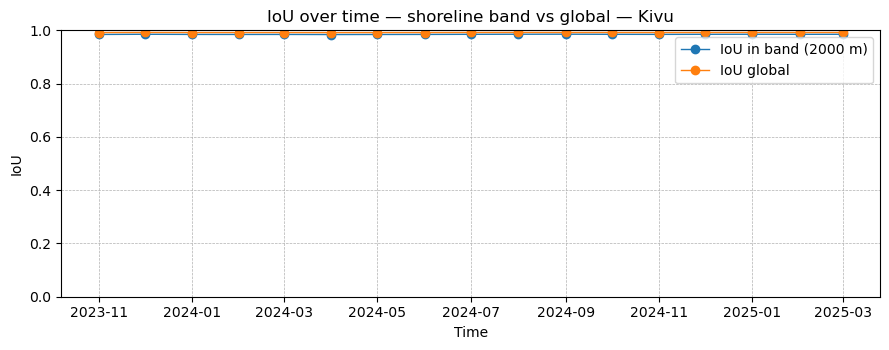

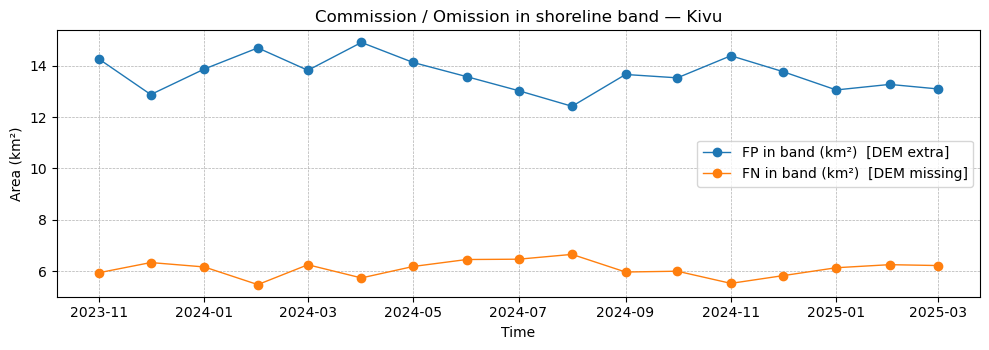

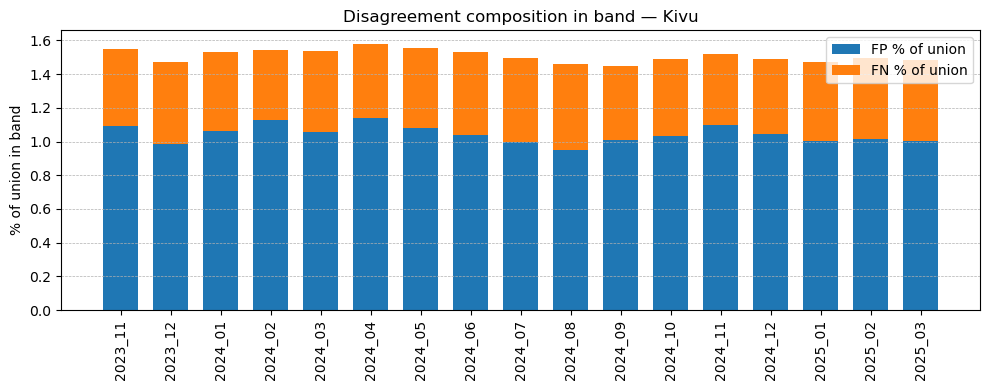

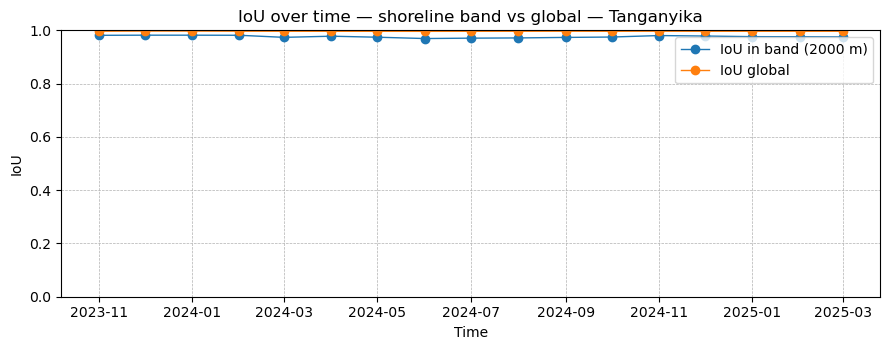

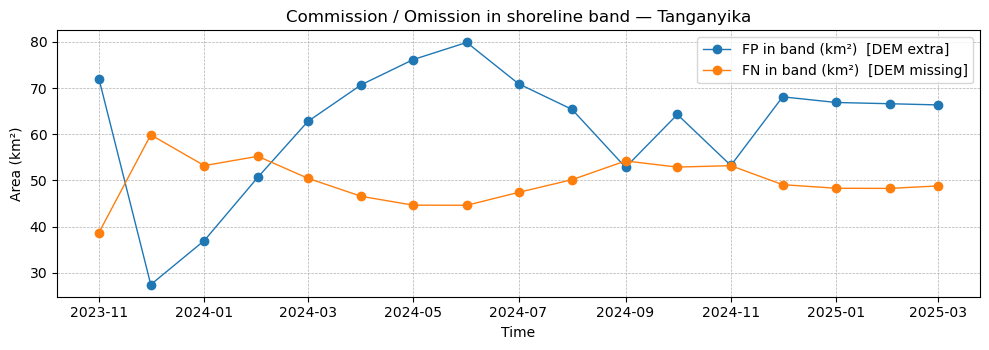

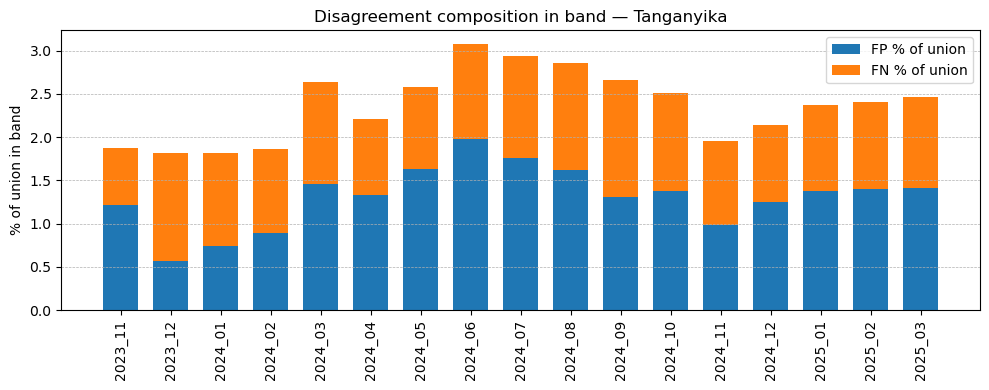

Shoreline plots saved → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\plots


In [14]:
# ==============================================================
# 10A) Shoreline-focused metrics — detailed confusion metrics in band
#      (CSV + plots: IoU over time, FP/FN time series, and stacked FP/FN %)
# ==============================================================

# Settings
SHORE_REF = "GEE"           # "GEE" (reference shoreline) or "DEM"
BAND_HALF_WIDTH_M = 2000.0  # e.g., 500/1000/2000 m
MAKE_PLOTS = True           # keep consistent with your global switch
SAVE_PNG_DPI = 150          # or reuse your existing variable

rows_shore = []

for lake, y, m, dem_path, gee_path in tqdm(pairs, desc="Shoreline IoU+", unit="pair"):
    work_crs = lake_to_workcrs[lake]
    A = read_single_multipart_polygon(dem_path, work_crs, dissolve=DISSOLVE_INPUTS, fix_invalid=FIX_INVALID)  # DEM
    B = read_single_multipart_polygon(gee_path, work_crs, dissolve=DISSOLVE_INPUTS, fix_invalid=FIX_INVALID)  # GEE
    if A is None or B is None or A.is_empty or B.is_empty:
        continue

    # Reference shoreline (where we build the band)
    ref = B if SHORE_REF.upper()=="GEE" else A

    # Band around shoreline (ring): +d minus -d
    band_outer = ref.buffer(BAND_HALF_WIDTH_M)
    band_inner = ref.buffer(-BAND_HALF_WIDTH_M)
    band = band_outer.difference(band_inner)
    if band.is_empty:
        continue

    # Restrict both sides to the band
    Ab = A.intersection(band)  # DEM-in-band
    Bb = B.intersection(band)  # GEE-in-band

    # Confusion areas within band
    inter = Ab.intersection(Bb)     # TP
    union = Ab.union(Bb)
    TP = area_km2(inter)
    A_in = area_km2(Ab)
    B_in = area_km2(Bb)
    FP = max(0.0, A_in - TP)        # DEM extra (commission)
    FN = max(0.0, B_in - TP)        # DEM missing (omission vs GEE)
    U  = area_km2(union)

    # Band-limited scores
    iou_band   = (TP / U) if U > 0 else np.nan
    dice_band  = (2*TP / (A_in + B_in)) if (A_in + B_in) > 0 else np.nan
    prec_band  = (TP / (TP + FP)) if (TP + FP) > 0 else np.nan
    rec_band   = (TP / (TP + FN)) if (TP + FN) > 0 else np.nan

    # FP/FN as share of union in band (focus on disagreement)
    fp_pct = (FP / U) if U > 0 else np.nan
    fn_pct = (FN / U) if U > 0 else np.nan

    rows_shore.append({
        "lake": lake, "year": y, "month": m,
        "band_width_m": BAND_HALF_WIDTH_M,
        "area_band_km2": area_km2(band),
        "A_in_band_km2": A_in,
        "B_in_band_km2": B_in,
        "TP_band_km2": TP,
        "FP_band_km2": FP,
        "FN_band_km2": FN,
        "union_band_km2": U,
        "iou_band": iou_band,
        "dice_band": dice_band,
        "precision_band": prec_band,
        "recall_band": rec_band,
        "fp_pct_of_union": fp_pct,
        "fn_pct_of_union": fn_pct
    })

df_shore_details = pd.DataFrame(rows_shore).sort_values(["lake","year","month"]).reset_index(drop=True)

# Merge in the global IoU/Dice for side-by-side plotting
per_month_csv = TABLES_DIR / "iou_per_month.csv"
if per_month_csv.exists():
    df_global = pd.read_csv(per_month_csv)
    df_global[["year","month"]] = df_global[["year","month"]].apply(pd.to_numeric, errors="coerce").astype("Int64")
    df_shore_details = df_shore_details.merge(
        df_global[["lake","year","month","iou","dice"]],
        on=["lake","year","month"], how="left", suffixes=("","_global")
    ).rename(columns={"iou":"iou_global","dice":"dice_global"})

# Save CSVs
shore_csv = TABLES_DIR / f"shoreline_iou_band_{int(BAND_HALF_WIDTH_M)}m.csv"
df_shore_details.to_csv(shore_csv, index=False, encoding="utf-8-sig")
print(f"Saved shoreline-band detailed metrics → {shore_csv}")

# ---------------- PLOTS ----------------
if MAKE_PLOTS and not df_shore_details.empty:
    for lake, sub in df_shore_details.groupby("lake", dropna=True):
        sub = sub.copy()
        sub["yyyymm"] = pd.to_datetime(sub["year"].astype(str)+"-"+sub["month"].astype(str)+"-01")

        # 1) IoU over time: band vs global (same axis; both in 0–1)
        plt.figure(figsize=(9,3.6))
        plt.plot(sub["yyyymm"], sub["iou_band"],   marker="o", linewidth=1, label=f"IoU in band ({int(BAND_HALF_WIDTH_M)} m)")
        if "iou_global" in sub.columns:
            plt.plot(sub["yyyymm"], sub["iou_global"], marker="o", linewidth=1, label="IoU global")
        plt.ylim(0, 1.0)
        plt.title(f"IoU over time — shoreline band vs global — {lake}")
        plt.xlabel("Time"); plt.ylabel("IoU")
        plt.grid(True, linestyle="--", linewidth=0.5)
        plt.legend()
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f"shore_iou_vs_global_{lake.lower()}_{int(BAND_HALF_WIDTH_M)}m.png", dpi=SAVE_PNG_DPI)
        plt.show()

        # 2) Commission vs Omission in band (km²)
        plt.figure(figsize=(10,3.6))
        plt.plot(sub["yyyymm"], sub["FP_band_km2"], marker="o", linewidth=1, label="FP in band (km²)  [DEM extra]")
        plt.plot(sub["yyyymm"], sub["FN_band_km2"], marker="o", linewidth=1, label="FN in band (km²)  [DEM missing]")
        plt.title(f"Commission / Omission in shoreline band — {lake}")
        plt.xlabel("Time"); plt.ylabel("Area (km²)")
        plt.grid(True, linestyle="--", linewidth=0.5)
        plt.legend()
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f"shore_fp_fn_timeseries_{lake.lower()}_{int(BAND_HALF_WIDTH_M)}m.png", dpi=SAVE_PNG_DPI)
        plt.show()

        # 3) Stacked bars: FP% vs FN% of union in band (disagreement composition)
        sub["month_label"] = sub["yyyymm"].dt.strftime("%Y_%m")
        x = np.arange(len(sub))
        width = 0.7
        plt.figure(figsize=(max(10, 0.5*len(sub)), 4.0))
        plt.bar(x, sub["fp_pct_of_union"]*100.0, width=width, label="FP % of union")
        plt.bar(x, sub["fn_pct_of_union"]*100.0, width=width, bottom=sub["fp_pct_of_union"]*100.0, label="FN % of union")
        plt.xticks(x, sub["month_label"], rotation=90)
        plt.ylabel("% of union in band")
        plt.title(f"Disagreement composition in band — {lake}")
        plt.grid(True, axis="y", linestyle="--", linewidth=0.5)
        plt.legend()
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f"shore_disagreement_stack_{lake.lower()}_{int(BAND_HALF_WIDTH_M)}m.png", dpi=SAVE_PNG_DPI, bbox_inches="tight")
        plt.show()

print(f"Shoreline plots saved → {PLOTS_DIR}")


In [ ]:
# ==============================================================
# 10B) OPTIONAL — Band width sensitivity curves (mean IoU over widths)
# ==============================================================

BAND_WIDTHS_M = [250, 500, 1000, 2000, 4000]

rows_bw = []
for lake, y, m, dem_path, gee_path in tqdm(pairs, desc="Shoreline width sweep", unit="pair"):
    work_crs = lake_to_workcrs[lake]
    A = read_single_multipart_polygon(dem_path, work_crs, dissolve=DISSOLVE_INPUTS, fix_invalid=FIX_INVALID)
    B = read_single_multipart_polygon(gee_path, work_crs, dissolve=DISSOLVE_INPUTS, fix_invalid=FIX_INVALID)
    if A is None or B is None or A.is_empty or B.is_empty:
        continue
    ref = B if SHORE_REF.upper()=="GEE" else A
    for w in BAND_WIDTHS_M:
        band = ref.buffer(w).difference(ref.buffer(-w))
        if band.is_empty:
            continue
        Ab = A.intersection(band)
        Bb = B.intersection(band)
        inter = Ab.intersection(Bb)
        union = Ab.union(Bb)
        U = area_km2(union)
        iou_band = (area_km2(inter) / U) if U > 0 else np.nan
        rows_bw.append({"lake":lake, "year":y, "month":m, "band_w_m":int(w), "iou_band":iou_band})

df_bw = pd.DataFrame(rows_bw)
bw_csv = TABLES_DIR / "shoreline_iou_bandwidth_sweep.csv"
df_bw.to_csv(bw_csv, index=False, encoding="utf-8-sig")
print(f"Saved band width sweep → {bw_csv}")

# Plot mean IoU vs width per lake
if MAKE_PLOTS and not df_bw.empty:
    for lake, sub in df_bw.groupby("lake"):
        plt.figure(figsize=(6,4))
        g = sub.groupby("band_w_m")["iou_band"].mean().reset_index()
        plt.plot(g["band_w_m"], g["iou_band"], marker="o", linewidth=1)
        plt.title(f"Mean shoreline IoU vs band width — {lake}")
        plt.xlabel("Band half-width (m)"); plt.ylabel("Mean IoU in band")
        plt.grid(True, linestyle="--", linewidth=0.5)
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f"shoreline_iou_vs_width_{lake.lower()}.png", dpi=SAVE_PNG_DPI)
        plt.show()


Shoreline width sweep:  32%|███▏      | 11/34 [17:28:38<29:12:11, 4570.94s/pair]

Terrain mismatch: 100%|██████████| 34/34 [28:43<00:00, 50.68s/pair] ﻿


Saved terrain stats for mismatch areas → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\tables\mismatch_terrain_stats.csv


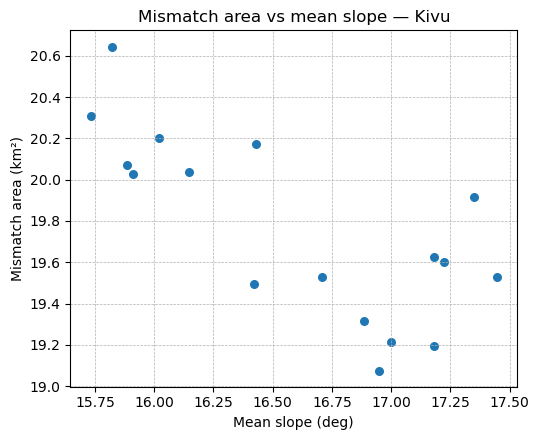

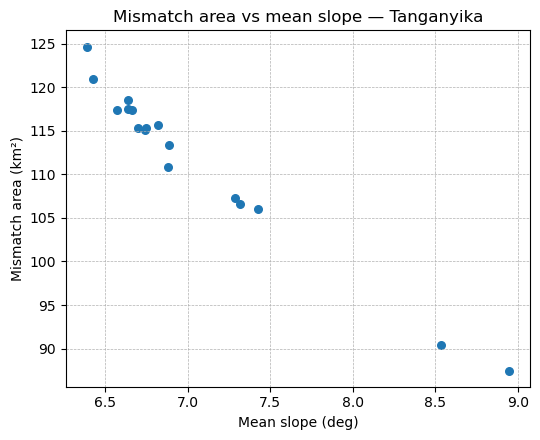

In [9]:
# ==============================================================
# 11) Terrain correlates — summarize slope/elevation in mismatch areas (FIXED MEM)
# ==============================================================

from rasterio.mask import mask as rio_mask
import rasterio
from shapely.geometry import mapping as shp_mapping

# Small helper: enable GDAL in-memory open for rasterize/mask
from contextlib import contextmanager
@contextmanager
def mem_ok():
    with rasterio.Env(GDAL_MEM_ENABLE_OPEN='YES'):
        yield

# Paths you provided
DEM_RASTERS = {
    "Tanganyika": {
        "elev": Path(r"C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\dem\FABDEM_TanganyikaB.tif"),
        "slope":Path(r"C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\dem\FABDEM_TanganyikaB_slope.tif")
    },
    "Kivu": {
        # same basin rasters; listed per-lake for clarity
        "elev": Path(r"C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\dem\FABDEM_TanganyikaB.tif"),
        "slope":Path(r"C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\dem\FABDEM_TanganyikaB_slope.tif")
    }
}

def _zonal_stats_raster(poly_work: sgeom.base.BaseGeometry, raster_path: Path, work_crs: CRS) -> Dict[str,float]:
    """
    Mask raster by polygon (reproject polygon to raster CRS), return simple stats.
    Uses GDAL_MEM_ENABLE_OPEN=YES to avoid MEM security error.
    """
    if not raster_path.exists() or poly_work.is_empty:
        return {"count":0,"mean":np.nan,"median":np.nan,"p10":np.nan,"p90":np.nan}

    with rasterio.open(raster_path) as ds:
        # Reproject polygon to raster CRS
        poly_rast = gpd.GeoSeries([poly_work], crs=work_crs).to_crs(ds.crs).iloc[0]

        # Mask with MEM enabled
        try:
            with mem_ok():
                # Ask for first band only; returns (1, H, W)
                out, _ = rio_mask(ds, [shp_mapping(poly_rast)], crop=True, indexes=[1])
        except ValueError as e:
            # Common case: polygon and raster do not overlap
            if "do not overlap" in str(e).lower():
                return {"count":0,"mean":np.nan,"median":np.nan,"p10":np.nan,"p90":np.nan}
            raise

        # out: (1, H, W) or (H, W) depending on rasterio version; normalize to 2-D
        arr = out[0] if out.ndim == 3 else out
        arr = arr.astype("float32", copy=False)

        # Apply nodata
        nod = ds.nodata
        if nod is not None and not np.isnan(nod):
            arr = np.where(arr == nod, np.nan, arr)

        vals = arr[np.isfinite(arr)]
        if vals.size == 0:
            return {"count":0,"mean":np.nan,"median":np.nan,"p10":np.nan,"p90":np.nan}

        return {
            "count": int(vals.size),
            "mean": float(np.nanmean(vals)),
            "median": float(np.nanmedian(vals)),
            "p10": float(np.nanpercentile(vals, 10)),
            "p90": float(np.nanpercentile(vals, 90))
        }

rows_terr = []
for lake, y, m, dem_path, gee_path in tqdm(pairs, desc="Terrain mismatch", unit="pair"):
    work_crs = lake_to_workcrs[lake]
    A = read_single_multipart_polygon(dem_path, work_crs, dissolve=True, fix_invalid=FIX_INVALID)
    B = read_single_multipart_polygon(gee_path, work_crs, dissolve=True, fix_invalid=FIX_INVALID)
    if A is None or B is None or A.is_empty or B.is_empty:
        continue

    sym = A.symmetric_difference(B)
    if sym.is_empty:
        continue

    elev_stats = _zonal_stats_raster(sym, DEM_RASTERS[lake]["elev"], work_crs)
    slope_stats= _zonal_stats_raster(sym, DEM_RASTERS[lake]["slope"], work_crs)

    rows_terr.append({
        "lake":lake, "year":y, "month":m,
        "mismatch_area_km2": area_km2(sym),
        "elev_mean":elev_stats["mean"], "elev_median":elev_stats["median"],
        "elev_p10":elev_stats["p10"], "elev_p90":elev_stats["p90"],
        "slope_mean":slope_stats["mean"], "slope_median":slope_stats["median"],
        "slope_p10":slope_stats["p10"], "slope_p90":slope_stats["p90"]
    })

df_terr = pd.DataFrame(rows_terr).sort_values(["lake","year","month"])
terr_csv = TABLES_DIR / "mismatch_terrain_stats.csv"
df_terr.to_csv(terr_csv, index=False, encoding="utf-8-sig")
print(f"Saved terrain stats for mismatch areas → {terr_csv}")

# Quick inline plot: mismatch area vs slope mean (kept as-is)
if MAKE_PLOTS and not df_terr.empty:
    for lake, sub in df_terr.groupby("lake"):
        plt.figure(figsize=(5.5,4.5))
        plt.scatter(sub["slope_mean"], sub["mismatch_area_km2"], s=30)
        plt.title(f"Mismatch area vs mean slope — {lake}")
        plt.xlabel("Mean slope (deg)"); plt.ylabel("Mismatch area (km²)")
        plt.grid(True, linestyle="--", linewidth=0.5)
        plt.tight_layout()
        out = PLOTS_DIR / f"mismatch_vs_slope_{lake.lower()}.png"
        plt.savefig(out, dpi=SAVE_PNG_DPI)
        plt.show()



[12A] Will process 6 lake-month(s).


12A mismatch-by-slope: 100%|██████████| 6/6 [02:22<00:00, 23.83s/lm]﻿


[12A] Saved summary CSV → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\tables\12A_mismatch_by_slope_summary.csv


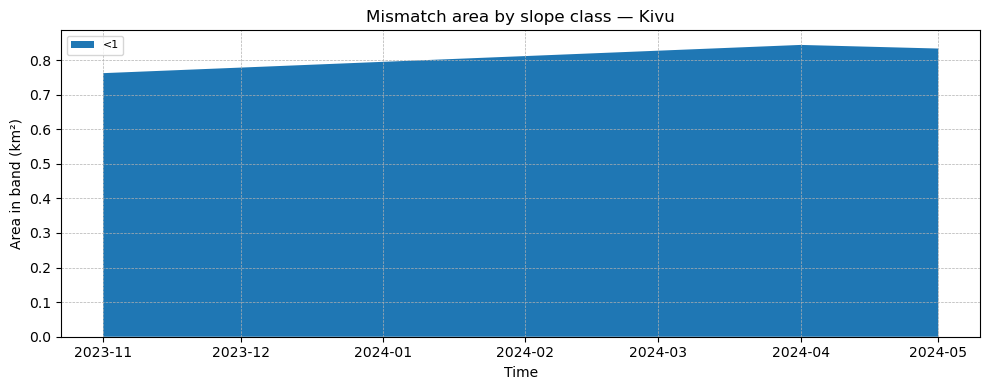

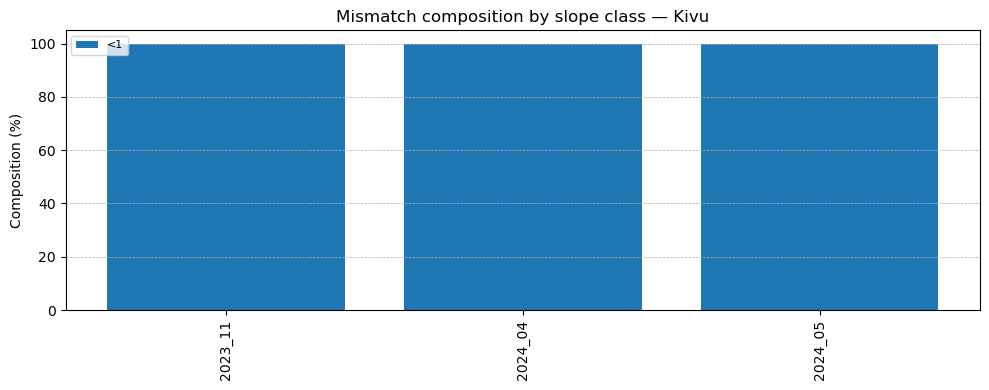

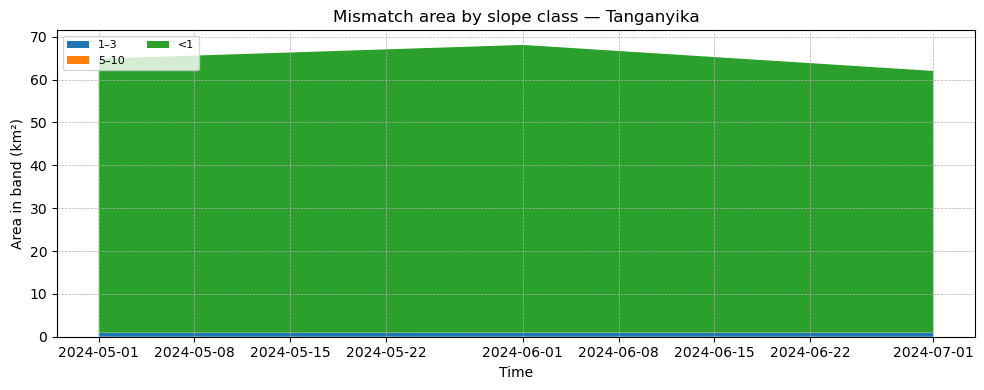

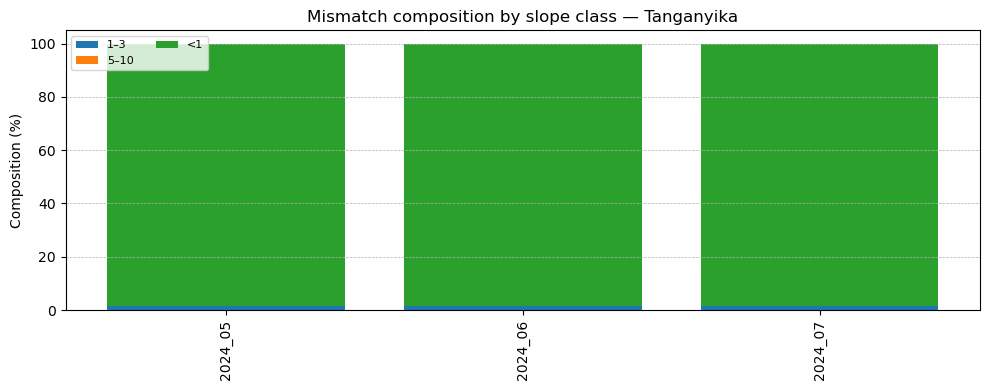

12A per-month bars:   0%|          | 0/6 [00:00<?, ?lm/s]

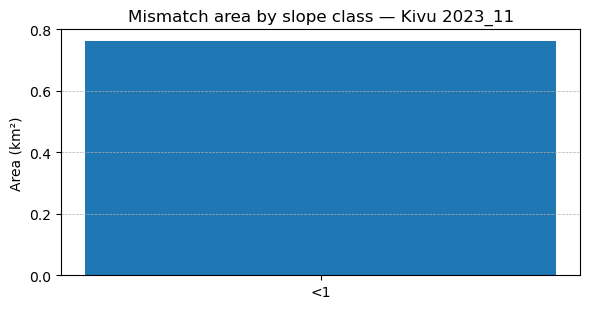

12A per-month bars:  17%|█▋        | 1/6 [00:00<00:00,  8.01lm/s]

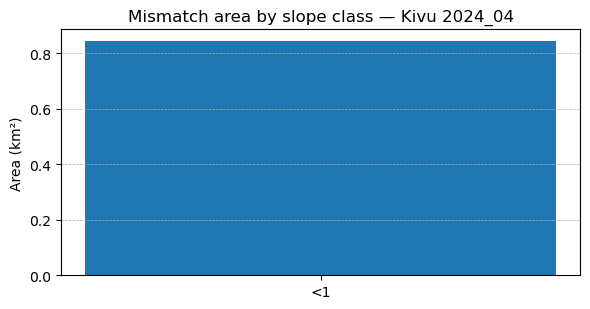

12A per-month bars:  33%|███▎      | 2/6 [00:00<00:00,  8.25lm/s]

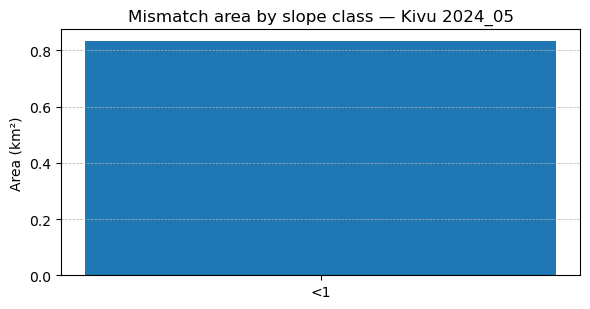

12A per-month bars:  50%|█████     | 3/6 [00:00<00:00,  8.37lm/s]

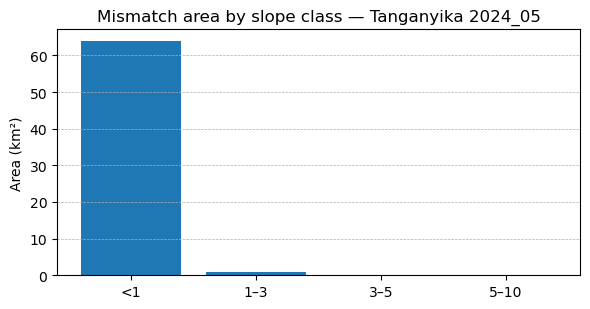

12A per-month bars:  67%|██████▋   | 4/6 [00:00<00:00,  7.47lm/s]

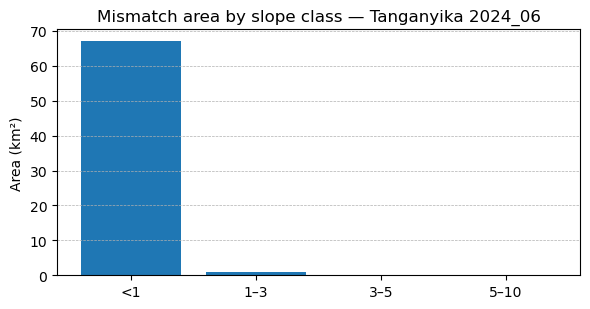

12A per-month bars:  83%|████████▎ | 5/6 [00:00<00:00,  6.35lm/s]

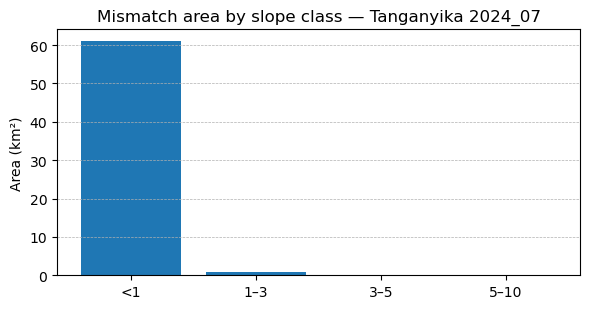

[12A] Plots saved → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\plots


In [11]:
# ==============================================================
# 12A) Mismatch-by-slope class (VECTOR) — polygonize slope classes inside A Δ B
#       Outputs:
#        • GPKG per lake-month (layer 'mismatch_by_slope', work CRS)
#        • CSV summary across months
#        • Plots: per-month class bars; per-lake stacked time series (area & %)
# ==============================================================

from rasterio.mask import mask as rio_mask
from rasterio.features import shapes as rio_shapes
import rasterio
from tqdm import tqdm

# ---- USER SETTINGS ----
SLOPE_CLASSES = [0, 1, 3, 5, 10, 20, 90]        # slope breakpoints (degrees)
SLOPE_LABELS  = ["<1", "1–3", "3–5", "5–10", "10–20", "≥20"]  # auto-capped to length
MIN_POLY_HA   = 5.0                              # drop polygons smaller than this (hectares)
RUN_MODE_12A  = "OUTLIERS"                       # "ALL" | "OUTLIERS" | "SINGLE"
RUN_SINGLE_YYYY_MM_12A = None                    # e.g., "2024_07" if RUN_MODE_12A == "SINGLE"
SAVE_PNG_DPI  = 150
MAKE_PLOTS    = True

VIS_DIR = IOU_ROOT / "visual"
A_DIR   = VIS_DIR / "12A_mismatch_by_slope"
A_DIR.mkdir(parents=True, exist_ok=True)

def _classify_slope(arr: np.ndarray) -> np.ndarray:
    bins = np.array(SLOPE_CLASSES, dtype="float32")
    cls = np.zeros(arr.shape, dtype="uint8")
    valid = np.isfinite(arr)
    for i in range(len(bins)-1):
        lo, hi = bins[i], bins[i+1]
        m = valid & (arr >= lo) & (arr < hi)
        cls[m] = i+1
    m_last = valid & (arr >= bins[-1])
    cls[m_last] = len(bins)
    return cls

def _select_months_for_12A():
    sel = []
    if RUN_MODE_12A.upper() == "SINGLE" and RUN_SINGLE_YYYY_MM_12A:
        y, m = map(int, RUN_SINGLE_YYYY_MM_12A.split("_"))
        for (lk, yy, mm), _ in find_gee_files().items():
            if lk in LAKES_TO_PROCESS and yy==y and mm==m:
                sel.append((lk, yy, mm))
    elif RUN_MODE_12A.upper() == "OUTLIERS":
        terr_csv = TABLES_DIR / "mismatch_terrain_stats.csv"
        if terr_csv.exists():
            tdf = pd.read_csv(terr_csv)
            for lk, sub in tdf.groupby("lake"):
                for _, r in sub.sort_values("mismatch_area_km2", ascending=False).head(3).iterrows():
                    sel.append((lk, int(r["year"]), int(r["month"])))
        else:
            df_pm = pd.read_csv(TABLES_DIR / "iou_per_month.csv")
            for lk, sub in df_pm.groupby("lake"):
                for _, r in sub.sort_values("symdiff_km2", ascending=False).head(3).iterrows():
                    sel.append((lk, int(r["year"]), int(r["month"])))
    else:  # ALL
        for (lk, yy, mm), _ in find_gee_files().items():
            if lk in LAKES_TO_PROCESS:
                sel.append((lk, yy, mm))
    return sorted(list(dict.fromkeys(sel)))

months_12A = _select_months_for_12A()
print(f"[12A] Will process {len(months_12A)} lake-month(s).")

# collect rows for summary/plots
rows_all = []

for lake, y, m in tqdm(months_12A, desc="12A mismatch-by-slope", unit="lm"):
    dem_path = find_dem_files().get((lake, y, m))
    gee_path = find_gee_files().get((lake, y, m))
    if dem_path is None or gee_path is None:
        continue

    work_crs = lake_to_workcrs[lake]
    A = read_single_multipart_polygon(dem_path, work_crs, dissolve=True, fix_invalid=FIX_INVALID)
    B = read_single_multipart_polygon(gee_path, work_crs, dissolve=True, fix_invalid=FIX_INVALID)
    if A is None or B is None or A.is_empty or B.is_empty:
        continue

    sym = A.symmetric_difference(B)
    if sym.is_empty:
        continue

    slope_path = DEM_RASTERS[lake]["slope"]
    with rasterio.open(slope_path) as ds:
        sym_r = gpd.GeoSeries([sym], crs=work_crs).to_crs(ds.crs).iloc[0]
        try:
            with mem_ok():
                slc, slc_transform = rio_mask(ds, [sgeom.mapping(sym_r)], crop=True, indexes=[1])
        except ValueError as e:
            if "do not overlap" in str(e).lower():
                continue
            else:
                raise

        arr = slc[0].astype("float32", copy=False)
        nod = ds.nodata
        if nod is not None and not np.isnan(nod):
            arr = np.where(arr == nod, np.nan, arr)

        cls = _classify_slope(arr)

        polys_by_cls = {}
        with mem_ok():
            for geom, val in rio_shapes(cls, mask=(cls > 0), transform=slc_transform, connectivity=8):
                cid = int(val)
                if cid <= 0: 
                    continue
                g = sgeom.shape(geom)
                if not g.is_empty:
                    polys_by_cls.setdefault(cid, []).append(g)

        records, geoms = [], []
        min_km2 = MIN_POLY_HA / 100.0
        for cid, glist in polys_by_cls.items():
            if not glist:
                continue
            mp = unary_union(glist)
            gseries = gpd.GeoSeries([mp], crs=ds.crs).explode(index_parts=False).reset_index(drop=True)
            gseries = gseries.to_crs(work_crs)
            for p in gseries.geometry:
                if p.is_empty:
                    continue
                akm2 = p.area / 1e6
                if akm2 >= min_km2:
                    records.append({
                        "lake": lake, "year": int(y), "month": int(m),
                        "sclass": cid, 
                        "label": SLOPE_LABELS[min(cid-1, len(SLOPE_LABELS)-1)],
                        "area_km2": float(akm2)
                    })
                    geoms.append(p)
        if not geoms:
            continue

        out_gdf = gpd.GeoDataFrame(records, geometry=geoms, crs=work_crs)
        gpkg = A_DIR / f"mismatch_by_slope_{lake}_{y:04d}_{m:02d}.gpkg"
        if gpkg.exists(): gpkg.unlink()
        out_gdf.to_file(gpkg, layer="mismatch_by_slope", driver="GPKG")

        # accumulate for plots
        rows_all.extend(records)

# ---- CSV summary & plots ----
if rows_all:
    dfA = pd.DataFrame(rows_all)
    dfA["yyyymm"] = pd.to_datetime(dfA["year"].astype(str) + "-" + dfA["month"].astype(str) + "-01")
    dfA.to_csv(TABLES_DIR / "12A_mismatch_by_slope_summary.csv", index=False, encoding="utf-8-sig")
    print(f"[12A] Saved summary CSV → {TABLES_DIR / '12A_mismatch_by_slope_summary.csv'}")

    if MAKE_PLOTS:
        # Per-lake stacked area by class over time (km²)
        for lake, sub in dfA.groupby("lake"):
            piv = sub.pivot_table(index="yyyymm", columns="label", values="area_km2", aggfunc="sum").fillna(0.0).sort_index()
            if piv.empty: 
                continue
            plt.figure(figsize=(max(10, 0.5*len(piv)), 4))
            plt.stackplot(piv.index, piv.T.values, labels=piv.columns)
            plt.title(f"Mismatch area by slope class — {lake}")
            plt.xlabel("Time"); plt.ylabel("Area in band (km²)")
            plt.legend(loc="upper left", ncol=2, fontsize=8)
            plt.grid(True, linestyle="--", linewidth=0.5)
            plt.tight_layout()
            out = PLOTS_DIR / f"12A_stacked_area_by_slope_{lake.lower()}.png"
            plt.savefig(out, dpi=SAVE_PNG_DPI)
            plt.show()

            # 100% stacked bars (composition)
            comp = piv.div(piv.sum(axis=1).replace(0, np.nan), axis=0)
            plt.figure(figsize=(max(10, 0.5*len(comp)), 4))
            bottom = np.zeros(len(comp))
            x = np.arange(len(comp))
            for lbl in comp.columns:
                vals = comp[lbl].values * 100.0
                plt.bar(x, vals, bottom=bottom, label=lbl, width=0.8)
                bottom += vals
            plt.xticks(x, [d.strftime("%Y_%m") for d in comp.index], rotation=90)
            plt.ylabel("Composition (%)"); plt.title(f"Mismatch composition by slope class — {lake}")
            plt.grid(True, axis="y", linestyle="--", linewidth=0.5)
            plt.legend(loc="upper left", ncol=2, fontsize=8)
            plt.tight_layout()
            out = PLOTS_DIR / f"12A_composition_by_slope_{lake.lower()}.png"
            plt.savefig(out, dpi=SAVE_PNG_DPI, bbox_inches="tight")
            plt.show()

        # Per-month bar chart (area by class)
        for (lake, y, m), sub in tqdm(dfA.groupby(["lake","year","month"]), desc="12A per-month bars", unit="lm", leave=False):
            g = sub.groupby("label")["area_km2"].sum().reindex(SLOPE_LABELS[:sub["sclass"].max()], fill_value=0.0)
            plt.figure(figsize=(6,3.2))
            plt.bar(g.index, g.values)
            plt.title(f"Mismatch area by slope class — {lake} {y:04d}_{m:02d}")
            plt.ylabel("Area (km²)")
            plt.grid(True, axis="y", linestyle="--", linewidth=0.5)
            plt.tight_layout()
            out = PLOTS_DIR / f"12A_bar_{lake.lower()}_{y:04d}_{m:02d}.png"
            plt.savefig(out, dpi=SAVE_PNG_DPI)
            plt.show()

print(f"[12A] Plots saved → {PLOTS_DIR}")


[12B] Will produce slope-in-mismatch rasters for 10 lake-month(s).


12B slope-in-mismatch:   0%|          | 0/10 [00:00<?, ?lm/s]

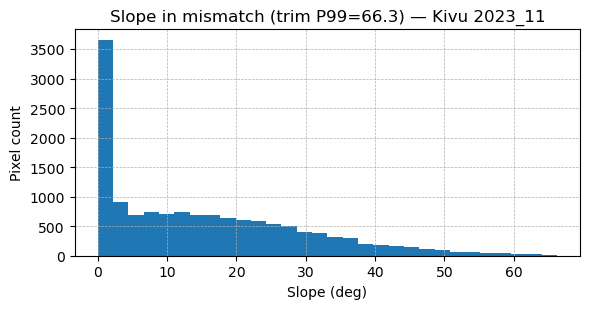

12B slope-in-mismatch:  10%|█         | 1/10 [00:04<00:41,  4.63s/lm]

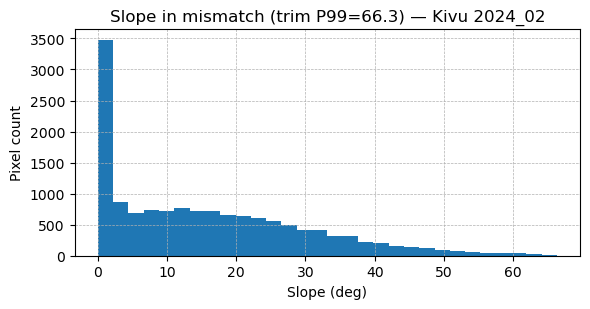

12B slope-in-mismatch:  20%|██        | 2/10 [00:09<00:37,  4.75s/lm]

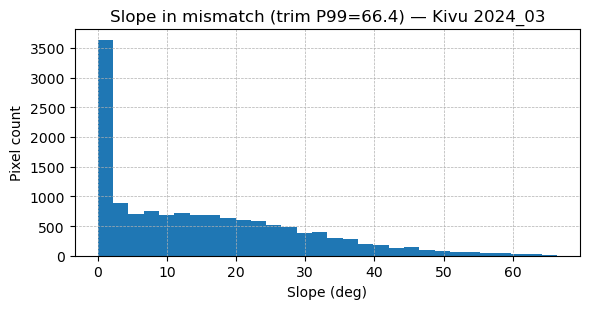

12B slope-in-mismatch:  30%|███       | 3/10 [00:13<00:32,  4.65s/lm]

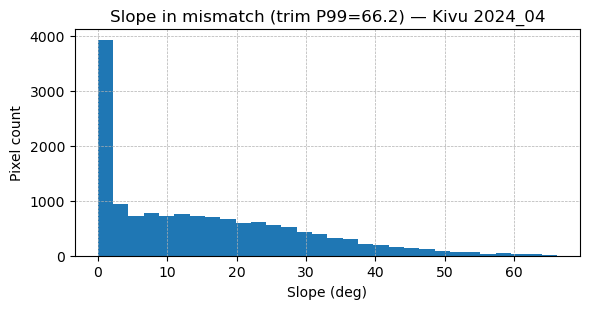

12B slope-in-mismatch:  40%|████      | 4/10 [00:18<00:27,  4.64s/lm]

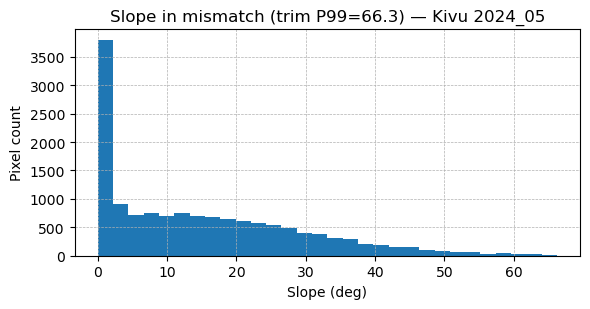

12B slope-in-mismatch:  50%|█████     | 5/10 [00:23<00:23,  4.61s/lm]

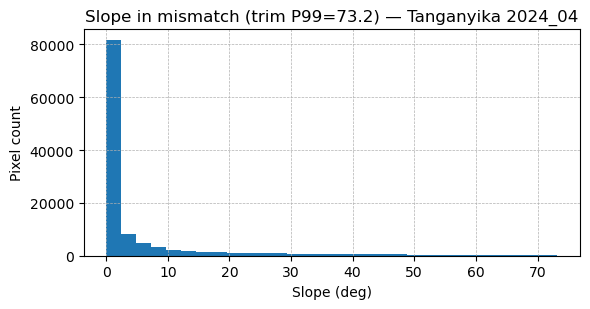

12B slope-in-mismatch:  60%|██████    | 6/10 [01:47<02:06, 31.64s/lm]

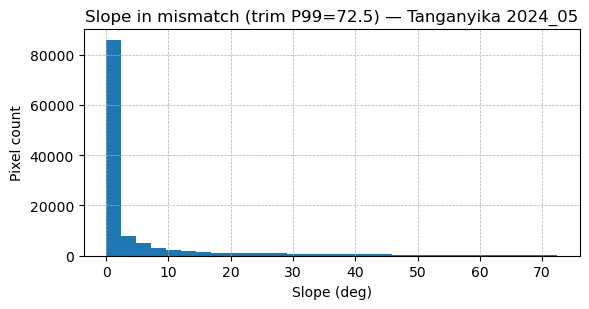

12B slope-in-mismatch:  70%|███████   | 7/10 [02:32<01:48, 36.18s/lm]

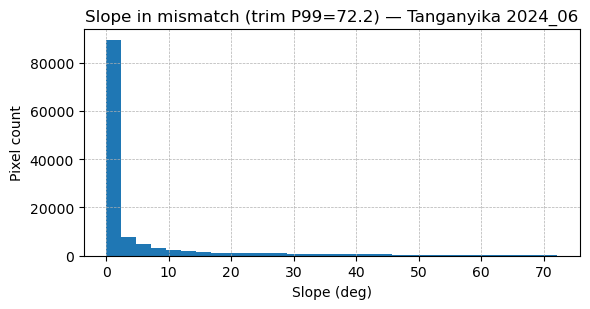

12B slope-in-mismatch:  80%|████████  | 8/10 [03:03<01:09, 34.54s/lm]

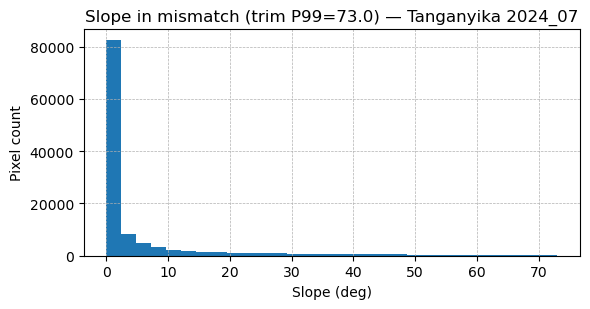

12B slope-in-mismatch:  90%|█████████ | 9/10 [03:31<00:32, 32.37s/lm]

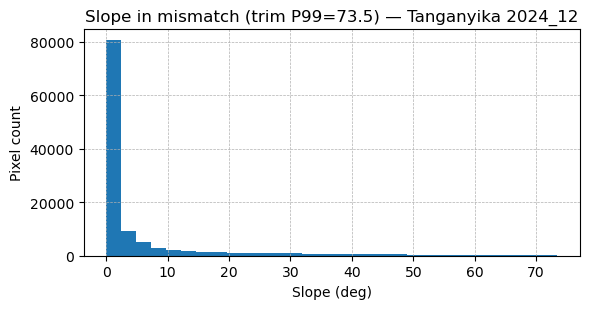

12B slope-in-mismatch: 100%|██████████| 10/10 [06:51<00:00, 41.11s/lm]﻿


[12B] Saved stats CSV → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\tables\12B_slope_in_mismatch_stats.csv


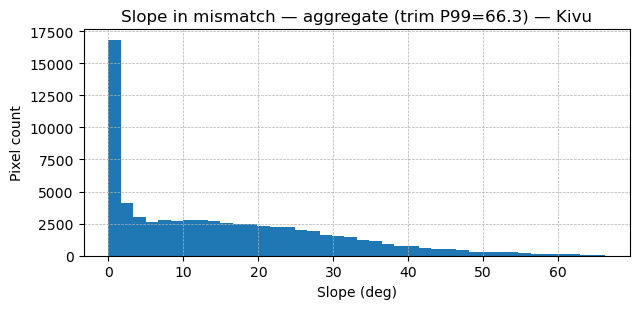

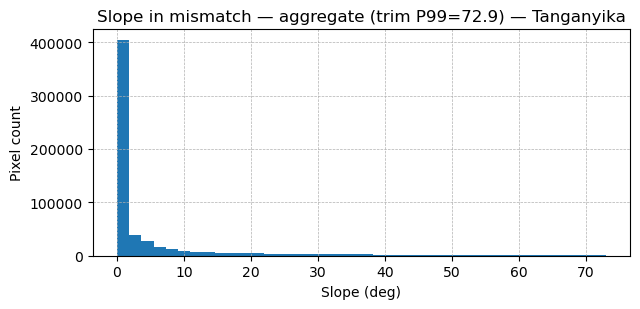

[12B] Rasters → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\visual\12B_slope_in_mismatch | Plots → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\plots


In [12]:
# ==============================================================
# 12B) Slope-in-mismatch (RASTER) — clip slope raster by A Δ B
#       Outputs:
#        • GeoTIFF per selected month
#        • CSV with slope distribution stats
#        • Plots: per-month histogram (trim P99) & per-lake aggregate histogram
# ==============================================================

from rasterio.mask import mask as rio_mask
import rasterio
from tqdm import tqdm

# ---- USER SETTINGS ----
TOP_N_PER_LAKE_12B = 5
RUN_MODE_12B = "OUTLIERS"                 # "OUTLIERS" | "ALL" | "SINGLE"
RUN_SINGLE_YYYY_MM_12B = None             # e.g., "2024_07"
SAVE_PNG_DPI  = 150
MAKE_PLOTS    = True

B_DIR = IOU_ROOT / "visual" / "12B_slope_in_mismatch"
B_DIR.mkdir(parents=True, exist_ok=True)

def _select_months_for_12B():
    sel = []
    if RUN_MODE_12B.upper() == "SINGLE" and RUN_SINGLE_YYYY_MM_12B:
        y, m = map(int, RUN_SINGLE_YYYY_MM_12B.split("_"))
        for (lk, yy, mm), _ in find_gee_files().items():
            if lk in LAKES_TO_PROCESS and yy==y and mm==m:
                sel.append((lk, yy, mm))
    elif RUN_MODE_12B.upper() == "ALL":
        for (lk, yy, mm), _ in find_gee_files().items():
            if lk in LAKES_TO_PROCESS:
                sel.append((lk, yy, mm))
    else:
        terr_csv = TABLES_DIR / "mismatch_terrain_stats.csv"
        if terr_csv.exists():
            tdf = pd.read_csv(terr_csv)
            for lk, sub in tdf.groupby("lake"):
                for _, r in sub.sort_values("mismatch_area_km2", ascending=False).head(TOP_N_PER_LAKE_12B).iterrows():
                    sel.append((lk, int(r["year"]), int(r["month"])))
        else:
            df_pm = pd.read_csv(TABLES_DIR / "iou_per_month.csv")
            for lk, sub in df_pm.groupby("lake"):
                for _, r in sub.sort_values("symdiff_km2", ascending=False).head(TOP_N_PER_LAKE_12B).iterrows():
                    sel.append((lk, int(r["year"]), int(r["month"])))
    return sorted(list(dict.fromkeys(sel)))

months_12B = _select_months_for_12B()
print(f"[12B] Will produce slope-in-mismatch rasters for {len(months_12B)} lake-month(s).")

rows_stats = []
lake_to_vals = {}

for lake, y, m in tqdm(months_12B, desc="12B slope-in-mismatch", unit="lm"):
    dem_path = find_dem_files().get((lake, y, m))
    gee_path = find_gee_files().get((lake, y, m))
    if dem_path is None or gee_path is None:
        continue

    work_crs = lake_to_workcrs[lake]
    A = read_single_multipart_polygon(dem_path, work_crs, dissolve=True, fix_invalid=FIX_INVALID)
    B = read_single_multipart_polygon(gee_path, work_crs, dissolve=True, fix_invalid=FIX_INVALID)
    if A is None or B is None or A.is_empty or B.is_empty:
        continue

    sym = A.symmetric_difference(B)
    if sym.is_empty:
        continue

    slope_tif = DEM_RASTERS[lake]["slope"]
    with rasterio.open(slope_tif) as ds:
        sym_r = gpd.GeoSeries([sym], crs=work_crs).to_crs(ds.crs).iloc[0]
        with mem_ok():
            out, out_transform = rio_mask(ds, [sgeom.mapping(sym_r)], crop=True, indexes=[1])
        data = out[0].astype("float32", copy=False)
        nod = ds.nodata
        if nod is not None and not np.isnan(nod):
            data = np.where(data == nod, np.nan, data)

        profile = ds.profile.copy()
        profile.update({
            "transform": out_transform,
            "height": data.shape[0],
            "width": data.shape[1],
            "compress": "DEFLATE",
            "tiled": True
        })
        tif_out = B_DIR / f"slope_in_mismatch_{lake}_{y:04d}_{m:02d}.tif"
        with rasterio.open(tif_out, "w", **profile) as dst:
            dst.write(data, 1)

        # stats for plots
        vals = data[np.isfinite(data)]
        if vals.size:
            lake_to_vals.setdefault(lake, []).append(vals)
            rows_stats.append({
                "lake": lake, "year": int(y), "month": int(m),
                "n": int(vals.size),
                "mean": float(np.mean(vals)),
                "median": float(np.median(vals)),
                "p90": float(np.percentile(vals, 90)),
                "max": float(np.max(vals))
            })

            if MAKE_PLOTS:
                p99 = float(np.percentile(vals, 99))
                plt.figure(figsize=(6,3.2))
                plt.hist(vals, bins=30, range=(0, p99))
                plt.title(f"Slope in mismatch (trim P99={p99:.1f}) — {lake} {y:04d}_{m:02d}")
                plt.xlabel("Slope (deg)"); plt.ylabel("Pixel count")
                plt.grid(True, linestyle="--", linewidth=0.5)
                plt.tight_layout()
                outp = PLOTS_DIR / f"12B_hist_{lake.lower()}_{y:04d}_{m:02d}.png"
                plt.savefig(outp, dpi=SAVE_PNG_DPI)
                plt.show()

# Save CSV
if rows_stats:
    dfB = pd.DataFrame(rows_stats).sort_values(["lake","year","month"])
    dfB.to_csv(TABLES_DIR / "12B_slope_in_mismatch_stats.csv", index=False, encoding="utf-8-sig")
    print(f"[12B] Saved stats CSV → {TABLES_DIR / '12B_slope_in_mismatch_stats.csv'}")

# Per-lake aggregate histogram
if MAKE_PLOTS and lake_to_vals:
    for lake, arrs in lake_to_vals.items():
        allv = np.concatenate(arrs) if arrs else np.array([])
        if allv.size == 0:
            continue
        p99 = float(np.percentile(allv, 99))
        plt.figure(figsize=(6.5,3.2))
        plt.hist(allv, bins=40, range=(0, p99))
        plt.title(f"Slope in mismatch — aggregate (trim P99={p99:.1f}) — {lake}")
        plt.xlabel("Slope (deg)"); plt.ylabel("Pixel count")
        plt.grid(True, linestyle="--", linewidth=0.5)
        plt.tight_layout()
        outp = PLOTS_DIR / f"12B_hist_aggregate_{lake.lower()}.png"
        plt.savefig(outp, dpi=SAVE_PNG_DPI)
        plt.show()

print(f"[12B] Rasters → {B_DIR} | Plots → {PLOTS_DIR}")


  Tanganyika months:  91%|█████████ | 39/43 [23:42<05:02, 75.52s/mo]﻿
                                                                    

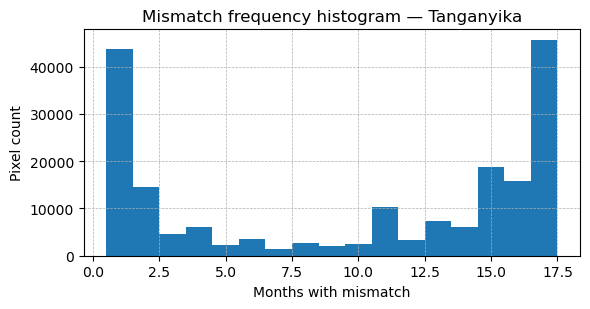

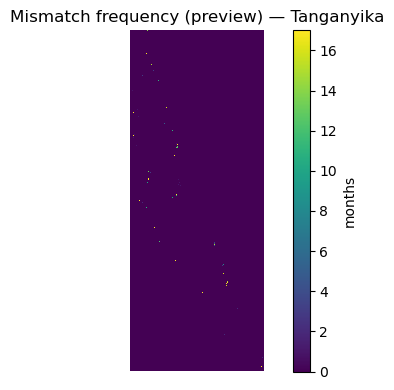

  Kivu months:  91%|█████████ | 39/43 [01:07<00:13,  3.25s/mo]﻿
                                                              

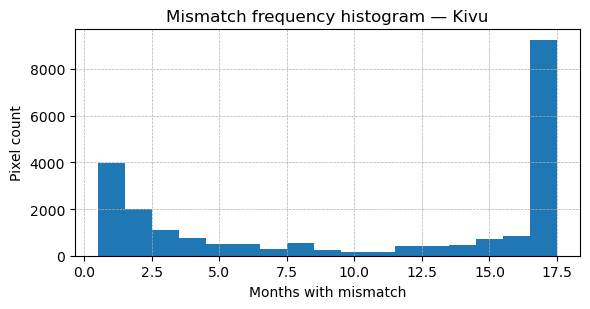

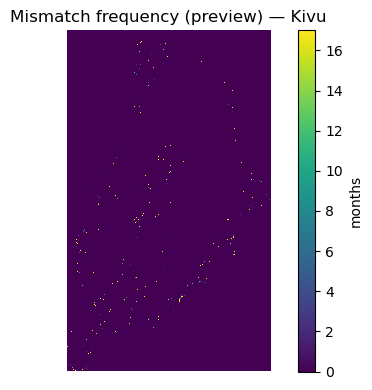

12C hotspots per lake: 100%|██████████| 2/2 [24:52<00:00, 746.41s/lake] ﻿


[12C] Rasters → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\visual\12C_hotspots | Plots → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\plots


In [13]:
# ==============================================================
# 12C) Hotspot frequency map — how many months show mismatch (raster)
#       Outputs:
#        • GeoTIFF per lake
#        • Plot: histogram of frequency counts + simple raster preview
# ==============================================================

import rasterio
from rasterio.features import rasterize
from rasterio.windows import from_bounds
from tqdm import tqdm

# ---- USER SETTINGS ----
SAVE_PNG_DPI  = 150
MAKE_PLOTS    = True

C_DIR = IOU_ROOT / "visual" / "12C_hotspots"
C_DIR.mkdir(parents=True, exist_ok=True)

for lake in tqdm(LAKES_TO_PROCESS, desc="12C hotspots per lake", unit="lake"):
    slope_tif = DEM_RASTERS[lake]["slope"]
    with rasterio.open(slope_tif) as ds:
        aoi = load_aoi(lake)  # WGS84 polygon
        aoi_r = gpd.GeoSeries([aoi], crs="EPSG:4326").to_crs(ds.crs).iloc[0]
        minx, miny, maxx, maxy = aoi_r.bounds
        win = from_bounds(minx, miny, maxx, maxy, ds.transform).round_offsets().round_lengths()
        transform = rasterio.windows.transform(win, ds.transform)
        out_shape = (int(win.height), int(win.width))

        freq = np.zeros(out_shape, dtype="uint16")

        all_months = sorted([(lk, y, m) for (lk, y, m) in find_gee_files().keys() if lk == lake],
                            key=lambda t: (t[1], t[2]))
        for _, y, m in tqdm(all_months, desc=f"  {lake} months", unit="mo", leave=False):
            dem_path = find_dem_files().get((lake, y, m))
            gee_path = find_gee_files().get((lake, y, m))
            if dem_path is None or gee_path is None:
                continue
            work_crs = lake_to_workcrs[lake]
            A = read_single_multipart_polygon(dem_path, work_crs, dissolve=True, fix_invalid=FIX_INVALID)
            B = read_single_multipart_polygon(gee_path, work_crs, dissolve=True, fix_invalid=FIX_INVALID)
            if A is None or B is None or A.is_empty or B.is_empty:
                continue
            sym = A.symmetric_difference(B)
            if sym.is_empty:
                continue
            sym_r = gpd.GeoSeries([sym], crs=work_crs).to_crs(ds.crs).iloc[0]
            with mem_ok():
                layer = rasterize(
                    [(sgeom.mapping(sym_r), 1)],
                    out_shape=out_shape,
                    transform=transform,
                    fill=0,
                    all_touched=False,
                    dtype="uint8"
                )
            freq += layer.astype("uint16")

        prof = ds.profile.copy()
        prof.update({
            "height": out_shape[0],
            "width": out_shape[1],
            "transform": transform,
            "count": 1,
            "dtype": "uint16",
            "compress": "DEFLATE",
            "tiled": True,
            "nodata": 0
        })
        tif_out = C_DIR / f"mismatch_frequency_{lake}.tif"
        with rasterio.open(tif_out, "w", **prof) as dst:
            dst.write(freq, 1)

        # ---- plots ----
        if MAKE_PLOTS:
            # histogram of frequency counts
            vals = freq.ravel()
            vals = vals[vals > 0]
            if vals.size:
                plt.figure(figsize=(6,3.2))
                plt.hist(vals, bins=np.arange(1, vals.max()+2)-0.5)
                plt.title(f"Mismatch frequency histogram — {lake}")
                plt.xlabel("Months with mismatch"); plt.ylabel("Pixel count")
                plt.grid(True, linestyle="--", linewidth=0.5)
                plt.tight_layout()
                out = PLOTS_DIR / f"12C_freq_hist_{lake.lower()}.png"
                plt.savefig(out, dpi=SAVE_PNG_DPI)
                plt.show()

            # simple raster preview
            plt.figure(figsize=(6,4))
            plt.imshow(freq, interpolation="nearest")
            plt.title(f"Mismatch frequency (preview) — {lake}")
            plt.colorbar(label="months")
            plt.axis("off")
            plt.tight_layout()
            out = PLOTS_DIR / f"12C_freq_preview_{lake.lower()}.png"
            plt.savefig(out, dpi=SAVE_PNG_DPI)
            plt.show()

print(f"[12C] Rasters → {C_DIR} | Plots → {PLOTS_DIR}")


[12D] Will export segments-with-slope for 6 lake-month(s).


  sampling slope:  92%|█████████▏| 1313/1429 [00:00<00:00, 6489.26seg/s]﻿
                                                                        

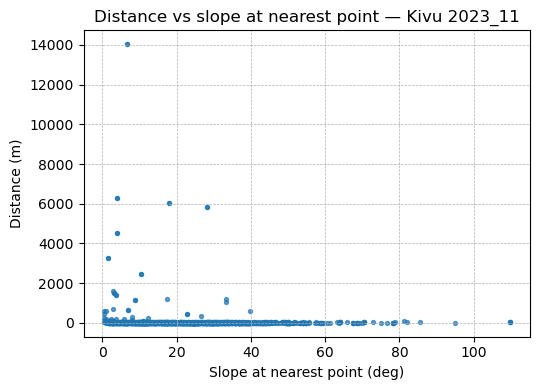

  sampling slope:  91%|█████████ | 1334/1462 [00:00<00:00, 6696.68seg/s]﻿
                                                                        

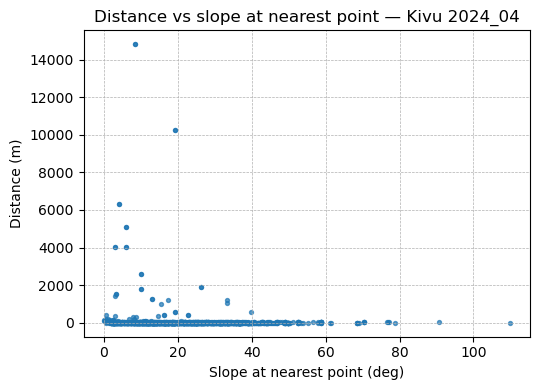

  sampling slope:  95%|█████████▍| 1343/1418 [00:00<00:00, 6708.29seg/s]﻿
                                                                        

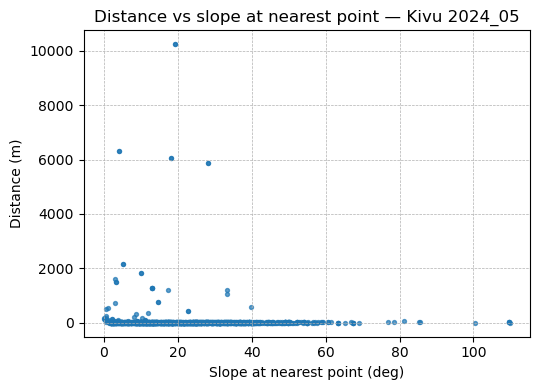

  sampling slope:  92%|█████████▏| 4515/4894 [00:00<00:00, 6146.00seg/s]﻿
                                                                        

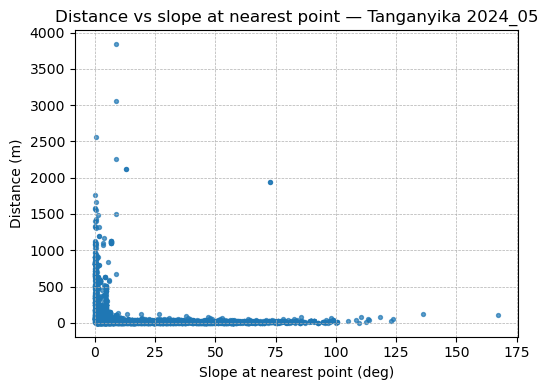

  sampling slope:  96%|█████████▌| 9778/10206 [00:01<00:00, 6084.59seg/s]﻿
                                                                         

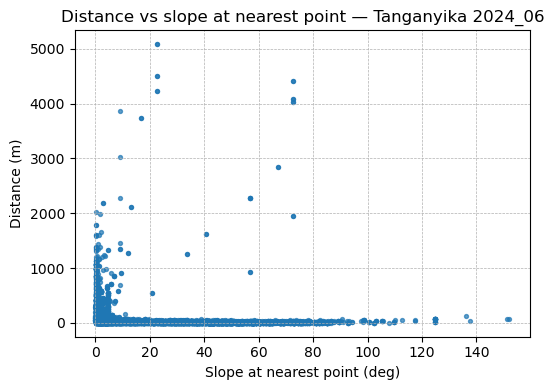

  sampling slope:  97%|█████████▋| 8307/8591 [00:01<00:00, 7035.70seg/s]﻿
                                                                        

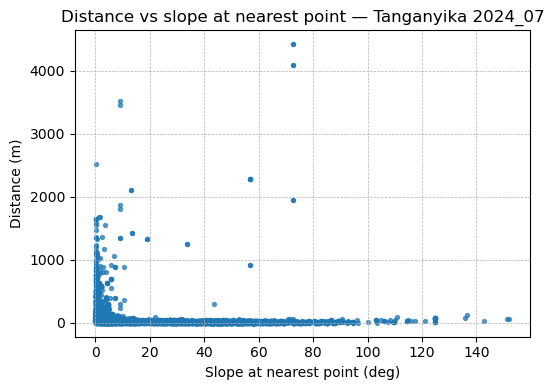

12D segments+slope: 100%|██████████| 6/6 [02:12<00:00, 22.04s/lm]﻿


[12D] Saved stats CSV → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\tables\12D_segments_stats.csv


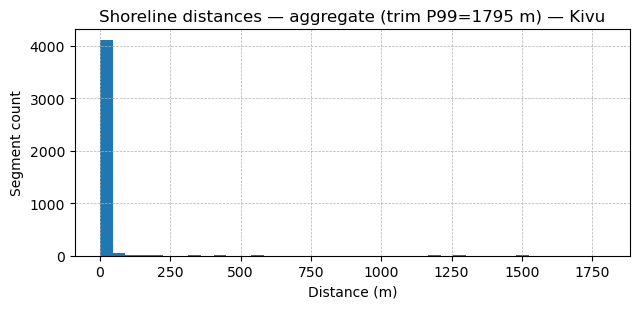

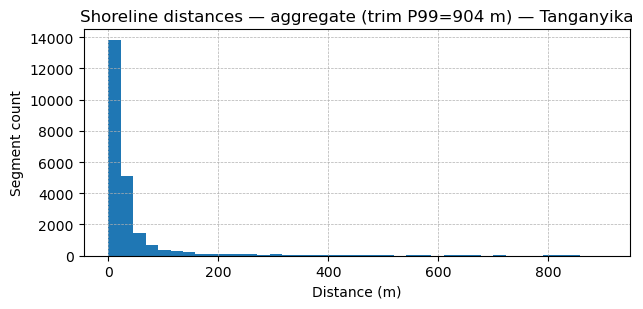

[12D] GPKGs → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\visual\12D_segments_with_slope | Plots → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\plots


In [14]:
# ==============================================================
# 12D) Nearest-shoreline segments with slope — micro QA
#       Outputs:
#        • GPKG per selected month (lines with dist_m + slope_d)
#        • CSV with per-month stats (mean/median/P90/max dist)
#        • Plots: per-month scatter (dist vs slope), per-lake dist hist
# ==============================================================

import rasterio
from shapely.ops import nearest_points
from pyproj import Transformer, CRS
from tqdm import tqdm

# ---- USER SETTINGS ----
RUN_MODE_12D = "OUTLIERS"    # "OUTLIERS" | "ALL" | "SINGLE"
RUN_SINGLE_YYYY_MM_12D = None
TOP_N_PER_LAKE_12D = 3
STEP_M_12D = float(BOUNDARY_SAMPLE_EVERY_M) if 'BOUNDARY_SAMPLE_EVERY_M' in globals() else 2000.0
SAVE_PNG_DPI  = 150
MAKE_PLOTS    = True

D_DIR = IOU_ROOT / "visual" / "12D_segments_with_slope"
D_DIR.mkdir(parents=True, exist_ok=True)

def _select_months_for_12D():
    sel = []
    if RUN_MODE_12D.upper() == "SINGLE" and RUN_SINGLE_YYYY_MM_12D:
        y, m = map(int, RUN_SINGLE_YYYY_MM_12D.split("_"))
        for (lk, yy, mm), _ in find_gee_files().items():
            if lk in LAKES_TO_PROCESS and yy==y and mm==m:
                sel.append((lk, yy, mm))
    elif RUN_MODE_12D.upper() == "OUTLIERS":
        terr_csv = TABLES_DIR / "mismatch_terrain_stats.csv"
        if terr_csv.exists():
            tdf = pd.read_csv(terr_csv)
            for lk, sub in tdf.groupby("lake"):
                for _, r in sub.sort_values("mismatch_area_km2", ascending=False).head(TOP_N_PER_LAKE_12D).iterrows():
                    sel.append((lk, int(r["year"]), int(r["month"])))
        else:
            df_pm = pd.read_csv(TABLES_DIR / "iou_per_month.csv")
            for lk, sub in df_pm.groupby("lake"):
                for _, r in sub.sort_values("symdiff_km2", ascending=False).head(TOP_N_PER_LAKE_12D).iterrows():
                    sel.append((lk, int(r["year"]), int(r["month"])))
    else:  # ALL
        for (lk, yy, mm), _ in find_gee_files().items():
            if lk in LAKES_TO_PROCESS: sel.append((lk, yy, mm))
    return sorted(list(dict.fromkeys(sel)))

def _boundary_lines(geom):
    polys = list(geom.geoms) if isinstance(geom, sgeom.MultiPolygon) else [geom]
    lines = [p.exterior for p in polys if isinstance(p, sgeom.Polygon)]
    return unary_union(lines) if lines else sgeom.MultiLineString([])

def _sample_line(line, step):
    if isinstance(line, sgeom.MultiLineString):
        pts = []
        for ls in line.geoms:
            if ls.length <= 0: continue
            n = max(2, int(np.ceil(ls.length/step))+1)
            ds = np.linspace(0, ls.length, n)
            pts += [ls.interpolate(float(d)) for d in ds]
        return pts
    else:
        if line.length <= 0: return []
        n = max(2, int(np.ceil(line.length/step))+1)
        ds = np.linspace(0, line.length, n)
        return [line.interpolate(float(d)) for d in ds]

months_12D = _select_months_for_12D()
print(f"[12D] Will export segments-with-slope for {len(months_12D)} lake-month(s).")

rows_stats = []
lake_to_d = {}

for lake, y, m in tqdm(months_12D, desc="12D segments+slope", unit="lm"):
    dem_path = find_dem_files().get((lake, y, m))
    gee_path = find_gee_files().get((lake, y, m))
    if dem_path is None or gee_path is None:
        continue

    work_crs = lake_to_workcrs[lake]
    A = read_single_multipart_polygon(dem_path, work_crs, dissolve=True, fix_invalid=FIX_INVALID)
    B = read_single_multipart_polygon(gee_path, work_crs, dissolve=True, fix_invalid=FIX_INVALID)
    if A is None or B is None or A.is_empty or B.is_empty:
        continue

    Ab = _boundary_lines(A); Bb = _boundary_lines(B)
    Apts = _sample_line(Ab, STEP_M_12D)
    Bpts = _sample_line(Bb, STEP_M_12D)

    segs = []
    for role, plist, other in [("DEM2GEE", Apts, Bb), ("GEE2DEM", Bpts, Ab)]:
        for P in plist:
            _, R = nearest_points(P, other)
            segs.append((role, P, R, float(P.distance(R))))

    slope_tif = DEM_RASTERS[lake]["slope"]
    with rasterio.open(slope_tif) as ds:
        if CRS.from_user_input(work_crs) != ds.crs:
            to_rast = Transformer.from_crs(work_crs, ds.crs, always_xy=True)
            def _to_rast_xy(x, y): return to_rast.transform(x, y)
        else:
            def _to_rast_xy(x, y): return (x, y)

        vals = []
        for role, P, R, d in tqdm(segs, desc="  sampling slope", unit="seg", leave=False):
            xr, yr = _to_rast_xy(R.x, R.y)
            for v in ds.sample([(xr, yr)]):
                slope_val = float(v[0]) if v.size else np.nan
            vals.append((role, P, R, d, slope_val))

    # Save GPKG
    seg_lines = [sgeom.LineString([(P.x, P.y), (R.x, R.y)]) for (_, P, R, _, _) in vals]
    gdf = gpd.GeoDataFrame({
        "lake": lake, "year": int(y), "month": int(m),
        "role": [t[0] for t in vals],
        "dist_m": [t[3] for t in vals],
        "slope_d": [t[4] for t in vals]
    }, geometry=seg_lines, crs=work_crs)
    gpkg = D_DIR / f"segments_with_slope_{lake}_{y:04d}_{m:02d}.gpkg"
    if gpkg.exists(): gpkg.unlink()
    gdf.to_file(gpkg, layer="segments", driver="GPKG")

    # stats row
    d_all = np.array([t[3] for t in vals], dtype="float64")
    lake_to_d.setdefault(lake, []).append(d_all)
    rows_stats.append({
        "lake": lake, "year": int(y), "month": int(m),
        "n": int(d_all.size),
        "mean_d": float(np.mean(d_all)) if d_all.size else np.nan,
        "median_d": float(np.median(d_all)) if d_all.size else np.nan,
        "p90_d": float(np.percentile(d_all, 90)) if d_all.size else np.nan,
        "max_d": float(np.max(d_all)) if d_all.size else np.nan
    })

    # per-month scatter
    if MAKE_PLOTS and len(vals) > 0:
        plt.figure(figsize=(5.5,4))
        plt.scatter([t[4] for t in vals], [t[3] for t in vals], s=8, alpha=0.7)
        plt.title(f"Distance vs slope at nearest point — {lake} {y:04d}_{m:02d}")
        plt.xlabel("Slope at nearest point (deg)"); plt.ylabel("Distance (m)")
        plt.grid(True, linestyle="--", linewidth=0.5)
        plt.tight_layout()
        out = PLOTS_DIR / f"12D_scatter_dist_vs_slope_{lake.lower()}_{y:04d}_{m:02d}.png"
        plt.savefig(out, dpi=SAVE_PNG_DPI)
        plt.show()

# Save CSV
if rows_stats:
    dfD = pd.DataFrame(rows_stats).sort_values(["lake","year","month"])
    dfD.to_csv(TABLES_DIR / "12D_segments_stats.csv", index=False, encoding="utf-8-sig")
    print(f"[12D] Saved stats CSV → {TABLES_DIR / '12D_segments_stats.csv'}")

# per-lake histogram of distances (aggregate selected months)
if MAKE_PLOTS and lake_to_d:
    for lake, arrs in lake_to_d.items():
        all_d = np.concatenate(arrs) if arrs else np.array([])
        if all_d.size == 0:
            continue
        p99 = float(np.percentile(all_d, 99))
        plt.figure(figsize=(6.5,3.2))
        plt.hist(all_d, bins=40, range=(0, p99))
        plt.title(f"Shoreline distances — aggregate (trim P99={p99:.0f} m) — {lake}")
        plt.xlabel("Distance (m)"); plt.ylabel("Segment count")
        plt.grid(True, linestyle="--", linewidth=0.5)
        plt.tight_layout()
        out = PLOTS_DIR / f"12D_hist_dist_aggregate_{lake.lower()}.png"
        plt.savefig(out, dpi=SAVE_PNG_DPI)
        plt.show()

print(f"[12D] GPKGs → {D_DIR} | Plots → {PLOTS_DIR}")


  Tanganyika early union: 100%|██████████| 24/24 [19:52<00:00, 52.42s/mo]﻿
                                                                         
  Tanganyika late union:  79%|███████▉  | 19/24 [25:53<05:02, 60.59s/mo]﻿
                                                                        

  Saved observed expansion → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\prone_areas\observed_expansion_Tanganyika.gpkg
  Saved raster prone-flat mask → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\prone_areas\prone_flat_mask_Tanganyika.tif
  Saved prone-flat polygons → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\prone_areas\prone_flat_polygons_Tanganyika.gpkg


  Kivu early union: 100%|██████████| 24/24 [00:37<00:00,  1.62s/mo]﻿
                                                                   
  Kivu late union:  79%|███████▉  | 19/24 [00:34<00:11,  2.34s/mo]﻿
                                                                  

  Saved observed expansion → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\prone_areas\observed_expansion_Kivu.gpkg
  Saved raster prone-flat mask → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\prone_areas\prone_flat_mask_Kivu.tif
  Saved prone-flat polygons → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\prone_areas\prone_flat_polygons_Kivu.gpkg


13 prone areas per lake: 100%|██████████| 2/2 [52:43<00:00, 1581.80s/lake]﻿


[13] Saved summary CSV → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\tables\13_prone_areas_summary.csv


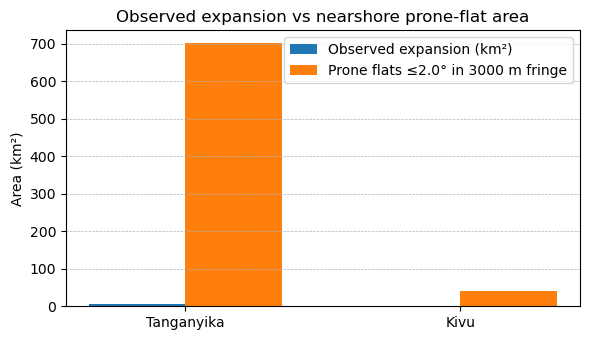

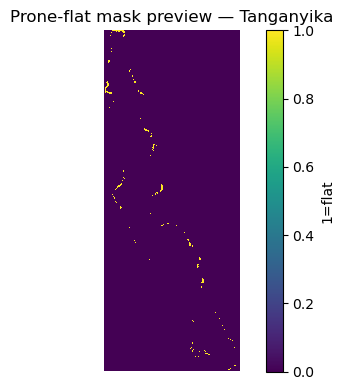

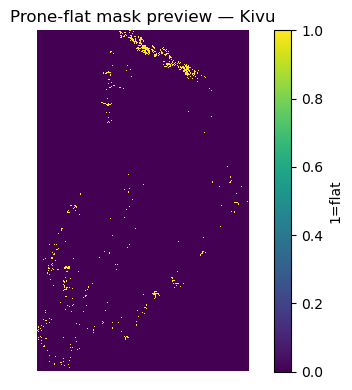

[13] Outputs → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\prone_areas | Plots → C:\Users\ibana\Desktop\JRC_Tanganica\GIS_Intermediate\Intermediate_files\SurfaceWater\IoU\stats\plots


In [15]:
# ==============================================================
# 13) Flat near-shore areas potentially prone to future inundation
#     (observed expansion since 2022 + potential flat-land fringe)
#     Outputs:
#       • GPKG observed expansion (per lake)
#       • Raster & GPKG of prone-flat mask (per lake)
#       • CSV summary
#       • Plots: bar chart of areas; preview of prone-flat mask
# ==============================================================

from rasterio.mask import mask as rio_mask
from rasterio.features import shapes as rio_shapes
import rasterio
from tqdm import tqdm

# ---- USER SETTINGS ----
EARLY_START = (2022, 1); EARLY_END = (2023, 12)
LATE_START  = (2024, 1); LATE_END  = (2025, 12)
FRINGE_OUTER_M     = 3000.0
FLAT_SLOPE_DEG_MAX = 2.0
MIN_POLY_HA_13     = 10.0
SAVE_PNG_DPI       = 150
MAKE_PLOTS         = True

OUT13_DIR = IOU_ROOT / "prone_areas"
OUT13_DIR.mkdir(parents=True, exist_ok=True)

def _months_in_range(start, end):
    ys, ms = start; ye, me = end
    out = []
    y, m = ys, ms
    while (y < ye) or (y == ye and m <= me):
        out.append((y, m))
        m += 1
        if m > 12:
            m = 1; y += 1
    return out

def _union_gee(lake, months, pb_desc="union"):
    geoms = []
    for (y, m) in tqdm(months, desc=f"  {lake} {pb_desc}", unit="mo", leave=False):
        gp = find_gee_files().get((lake, y, m))
        if gp is None: continue
        g = read_single_multipart_polygon(gp, lake_to_workcrs[lake], dissolve=True, fix_invalid=FIX_INVALID)
        if g is None or g.is_empty: continue
        geoms.append(g)
    if not geoms: return None
    return unary_union(geoms)

def _clip_slope_to_poly(poly_work, slope_path, work_crs):
    with rasterio.open(slope_path) as ds:
        poly_r = gpd.GeoSeries([poly_work], crs=work_crs).to_crs(ds.crs).iloc[0]
        with mem_ok():
            arr, tr = rio_mask(ds, [sgeom.mapping(poly_r)], crop=True, indexes=[1])
        data = arr[0].astype("float32")
        nod = ds.nodata
        if nod is not None and not np.isnan(nod):
            data = np.where(data==nod, np.nan, data)
        prof = ds.profile.copy()
        prof.update({"transform": tr, "height": data.shape[0], "width": data.shape[1],
                     "compress":"DEFLATE","tiled":True})
        return data, tr, prof

def _raster_to_vector_mask(data, transform, crs, cond_mask, min_ha, work_crs):
    geoms = []
    with mem_ok():
        for geom, val in rio_shapes(cond_mask.astype("uint8"), mask=cond_mask, transform=transform, connectivity=8):
            if int(val) != 1: continue
            g = sgeom.shape(geom)
            if g.is_empty: continue
            geoms.append(g)
    if not geoms:
        return gpd.GeoDataFrame({"area_km2":[]}, geometry=[], crs=crs)
    gdf_r = gpd.GeoDataFrame(geometry=geoms, crs=crs).to_crs(work_crs)
    gdf_r["area_km2"] = gdf_r.area / 1e6
    gdf_r = gdf_r[gdf_r["area_km2"] >= (min_ha/100.0)].copy()
    return gdf_r

rows_sum = []

for lake in tqdm(LAKES_TO_PROCESS, desc="13 prone areas per lake", unit="lake"):
    work_crs = lake_to_workcrs[lake]
    slope_tif = DEM_RASTERS[lake]["slope"]

    early_months = _months_in_range(EARLY_START, EARLY_END)
    late_months  = _months_in_range(LATE_START, LATE_END)

    Uearly = _union_gee(lake, early_months, pb_desc="early union")
    Ulate  = _union_gee(lake, late_months,  pb_desc="late union")
    if Ulate is None:
        print(f"  No late-window polygons for {lake}; skipping.")
        continue

    # Observed expansion
    gpkg_obs = OUT13_DIR / f"observed_expansion_{lake}.gpkg"
    if gpkg_obs.exists(): gpkg_obs.unlink()

    exp_area_km2 = 0.0
    if Uearly is not None:
        exp_poly = Ulate.difference(Uearly)
        if not exp_poly.is_empty:
            parts = list(exp_poly.geoms) if isinstance(exp_poly, sgeom.MultiPolygon) else [exp_poly]
            gdf_exp = gpd.GeoDataFrame(
                {"lake":[lake]*len(parts), "area_km2":[float(gpd.GeoSeries([p], crs=work_crs).area.iloc[0]/1e6) for p in parts]},
                geometry=parts, crs=work_crs
            )
            exp_area_km2 = float(gdf_exp["area_km2"].sum())
            gdf_exp.to_file(gpkg_obs, layer="observed_expansion", driver="GPKG")
            print(f"  Saved observed expansion → {gpkg_obs}")
        else:
            print("  No observed expansion after early-vs-late diff.")
    else:
        print("  Early window empty; skipping observed expansion.")

    # Potential susceptibility: flat land within FRINGE_OUTER_M outside latest water
    band_outside = Ulate.buffer(FRINGE_OUTER_M).difference(Ulate)
    data, tr, prof = _clip_slope_to_poly(band_outside, slope_tif, work_crs)
    flat_mask = np.isfinite(data) & (data <= FLAT_SLOPE_DEG_MAX)

    # Save raster mask
    tif_flat = OUT13_DIR / f"prone_flat_mask_{lake}.tif"
    with rasterio.open(tif_flat, "w", **prof) as dst:
        arr = np.where(flat_mask, 1, 0).astype("uint8")
        dst.write(arr, 1)
        dst.update_tags(descr="1=flat (slope<=threshold) within nearshore band outside latest water")
    print(f"  Saved raster prone-flat mask → {tif_flat}")

    # Vectorize flat mask (filter small) and save
    gdf_flat = _raster_to_vector_mask(data, tr, prof["crs"], flat_mask, MIN_POLY_HA_13, work_crs)
    prone_area_km2 = float(gdf_flat["area_km2"].sum()) if not gdf_flat.empty else 0.0
    if not gdf_flat.empty:
        gpkg_flat = OUT13_DIR / f"prone_flat_polygons_{lake}.gpkg"
        if gpkg_flat.exists(): gpkg_flat.unlink()
        gdf_flat.to_file(gpkg_flat, layer="prone_flat", driver="GPKG")
        print(f"  Saved prone-flat polygons → {gpkg_flat}")
    else:
        print("  No prone-flat polygons above area threshold.")

    rows_sum.append({"lake":lake,
                     "observed_expansion_km2": exp_area_km2,
                     "prone_flat_km2": prone_area_km2,
                     "fringe_m": FRINGE_OUTER_M,
                     "flat_thresh_deg": FLAT_SLOPE_DEG_MAX})

# Summary CSV & plots
if rows_sum:
    df13 = pd.DataFrame(rows_sum)
    df13.to_csv(TABLES_DIR / "13_prone_areas_summary.csv", index=False, encoding="utf-8-sig")
    print(f"[13] Saved summary CSV → {TABLES_DIR / '13_prone_areas_summary.csv'}")

    if MAKE_PLOTS:
        # bars per lake
        idx = np.arange(len(df13))
        w = 0.35
        plt.figure(figsize=(6,3.5))
        plt.bar(idx - w/2, df13["observed_expansion_km2"], width=w, label="Observed expansion (km²)")
        plt.bar(idx + w/2, df13["prone_flat_km2"], width=w, label=f"Prone flats ≤{FLAT_SLOPE_DEG_MAX}° in {int(FRINGE_OUTER_M)} m fringe")
        plt.xticks(idx, df13["lake"])
        plt.ylabel("Area (km²)")
        plt.title("Observed expansion vs nearshore prone-flat area")
        plt.grid(True, axis="y", linestyle="--", linewidth=0.5)
        plt.legend()
        plt.tight_layout()
        out = PLOTS_DIR / "13_prone_areas_bars.png"
        plt.savefig(out, dpi=SAVE_PNG_DPI)
        plt.show()

        # quick preview of last computed prone mask (for each lake)
        for lake in df13["lake"]:
            tif_flat = OUT13_DIR / f"prone_flat_mask_{lake}.tif"
            if tif_flat.exists():
                with rasterio.open(tif_flat) as ds:
                    arr = ds.read(1)
                plt.figure(figsize=(5.5,4))
                plt.imshow(arr, interpolation="nearest")
                plt.title(f"Prone-flat mask preview — {lake}")
                plt.axis("off"); plt.colorbar(label="1=flat")
                plt.tight_layout()
                out = PLOTS_DIR / f"13_prone_mask_preview_{lake.lower()}.png"
                plt.savefig(out, dpi=SAVE_PNG_DPI)
                plt.show()

print(f"[13] Outputs → {OUT13_DIR} | Plots → {PLOTS_DIR}")
